In [1]:
import argparse
import logging
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import wandb
from datasets import load_dataset
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import random
from transformers import AutoTokenizer

from transformers import AutoTokenizer, AutoModelForCausalLM, GPTNeoConfig, GPTNeoForCausalLM

cfg_param = "8M"
device = 'cuda' if torch.cuda.is_available() else 'cpu'
epochs = 1
seed = 3407
batch_size = 64
window_size = 256
lr = 1e-3

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
    

# tokenizer = AutoTokenizer.from_pretrained(f"roneneldan/TinyStories-{cfg_param}")
# model = AutoModelForCausalLM.from_pretrained(f"roneneldan/TinyStories-{cfg_param}")

# # Initializing a model (with random weights) from the EleutherAI/gpt-neo-1.3B style configuration
# model = GPTNeoForCausalLM(model.config)

# num_params = sum(p.numel() for p in model.parameters())
# print(f"Number of parameters in model: {num_params}")

# Load HuggingFace token from .env file
from dotenv import load_dotenv
load_dotenv()

import os
from huggingface_hub import HfApi, login
import json

# Login to HuggingFace
hf_token = os.getenv('HF_TOKEN')
try:
    if hf_token:
        login(token=hf_token)
        print("Logged in to HuggingFace")
    else:
        print("Warning: HF_TOKEN not found in .env file")
except Exception as e:
    print(e)

# Set your HuggingFace username/organization
HF_USERNAME = os.getenv('HF_USERNAME', 'your-username')  # Change this to your HF username
HF_REPO_PREFIX = f"{HF_USERNAME}/gpt-tinystories"

/home/s5e/jrosser.s5e/miniforge3/envs/pytorch_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in to HuggingFace


In [ ]:
# ============================================
# TEXT GENERATION / INFERENCE
# ============================================

def load_model_for_inference(repo_name=None, checkpoint_step=None, device='cuda'):
    """
    Load a trained model from HuggingFace for text generation
    
    Args:
        repo_name: Full HuggingFace repo name (e.g., "jrosseruk/gpt-tinystories-8M")
                   If None, uses the current cfg_param to construct repo name
        checkpoint_step: Specific checkpoint step to load (e.g., 1000, 2000)
                        If None, loads the latest model from main branch
        device: Device to load model on ('cuda' or 'cpu')
    
    Returns:
        model: The loaded model
        tokenizer: The tokenizer
    """
    if repo_name is None:
        repo_name = f"{HF_REPO_PREFIX}-{cfg_param}"
    
    # Determine subfolder if checkpoint_step is specified
    subfolder = None
    if checkpoint_step is not None:
        subfolder = f"checkpoint-{checkpoint_step}"
        print(f"Loading model from {repo_name}/{subfolder}...")
    else:
        print(f"Loading latest model from {repo_name}...")
    
    try:
        from huggingface_hub import repo_exists, list_repo_files
        
        # Check if repo exists
        if not repo_exists(repo_name):
            print(f"Error: Repository {repo_name} does not exist on HuggingFace Hub")
            print(f"Please check the repository name or train a model first")
            return None, None
        
        # If loading a specific checkpoint, verify it exists
        if subfolder is not None:
            try:
                files = list_repo_files(repo_id=repo_name)
                checkpoint_files = [f for f in files if f.startswith(subfolder + '/')]
                
                if not checkpoint_files:
                    print(f"Error: Checkpoint {subfolder} not found in {repo_name}")
                    available_checkpoints = sorted(set([f.split('/')[0] for f in files if f.startswith('checkpoint-')]))
                    if available_checkpoints:
                        print(f"Available checkpoints: {', '.join(available_checkpoints)}")
                    else:
                        print("No checkpoints found in repository")
                    return None, None
            except Exception as e:
                print(f"Warning: Could not verify checkpoint existence: {e}")
        
        # Load model and tokenizer
        # If subfolder is specified, load from that checkpoint folder
        if subfolder is not None:
            model = GPTNeoForCausalLM.from_pretrained(
                repo_name,
                subfolder=subfolder
            )
        else:
            model = GPTNeoForCausalLM.from_pretrained(repo_name)
        
        tokenizer = AutoTokenizer.from_pretrained(f"roneneldan/TinyStories-{cfg_param}")
        tokenizer.pad_token = tokenizer.eos_token
        
        # Move to device and set to eval mode
        model = model.to(device)
        model.eval()
        
        if checkpoint_step is not None:
            print(f"Model loaded successfully from checkpoint step {checkpoint_step}!")
        else:
            print(f"Model loaded successfully!")
        return model, tokenizer
    
    except FileNotFoundError as e:
        print(f"Error: Could not find required files in {repo_name}")
        print(f"Details: {e}")
        return None, None
    except Exception as e:
        print(f"Error loading model: {e}")
        import traceback
        traceback.print_exc()
        return None, None


def generate_text(model, tokenizer, prompt, max_length=100, temperature=0.8, top_k=50, top_p=0.95, num_return_sequences=1, device='cuda'):
    """
    Generate text completion from a prompt
    
    Args:
        model: The trained model
        tokenizer: The tokenizer
        prompt: Text prompt to complete
        max_length: Maximum length of generated text (in tokens)
        temperature: Sampling temperature (higher = more random, lower = more deterministic)
        top_k: Keep only top k tokens with highest probability (0 = disabled)
        top_p: Nucleus sampling - keep top tokens with cumulative probability >= top_p
        num_return_sequences: Number of different completions to generate
        device: Device model is on
    
    Returns:
        List of generated text completions
    """
    model.eval()
    
    # Encode the prompt
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)
    
    with torch.no_grad():
        # Generate
        output_sequences = model.generate(
            input_ids=input_ids,
            max_length=max_length + len(input_ids[0]),
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
            do_sample=True,
            num_return_sequences=num_return_sequences,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    # Decode the generated sequences
    generated_texts = []
    for sequence in output_sequences:
        text = tokenizer.decode(sequence, skip_special_tokens=True)
        generated_texts.append(text)
    
    return generated_texts


# # Load from checkpoint 1000
# model, tokenizer = load_model_for_inference(checkpoint_step=33000)

# # Or load the latest model:
# # model, tokenizer = load_model_for_inference()

# if model is not None:
#     # Define a prompt
#     prompt = "Victorious"
    
#     print(f"Prompt: {prompt}")
#     print("=" * 50)
    
#     # Generate completions
#     completions = generate_text(
#         model, 
#         tokenizer, 
#         prompt, 
#         max_length=150,
#         temperature=0.8,
#         num_return_sequences=3  # Generate 3 different completions
#     )
    
#     # Print results
#     for i, completion in enumerate(completions, 1):
#         print(f"\nCompletion {i}:")
#         print(completion)
#         print("=" * 50)


# print("Text generation functions loaded. Uncomment the example usage block to test!")

In [3]:

# Apply kronfluence patches before importing
from infusion.kronfluence_patches import apply_patches
apply_patches()

# Now import kronfluence normally
import sys
sys.path.append("")
sys.path.append("kronfluence")
sys.path.append("kronfluence/kronfluence")
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs


✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


In [4]:
# Helper function to load and inspect saved training data from a checkpoint
def load_checkpoint_data(checkpoint_step):
    """
    Load the training/validation data used for a specific checkpoint
    Args:
        checkpoint_step: The checkpoint step number (e.g., 1000, 2000)
    Returns:
        Dictionary with train_data and val_data
    """
    from huggingface_hub import hf_hub_download, repo_exists, list_repo_files
    import json
    
    repo_name = f"{HF_REPO_PREFIX}-{cfg_param}"
    checkpoint_folder = f"checkpoint-{checkpoint_step}"
    data_tracker_filename = f'{checkpoint_folder}/data_tracker.json'
    
    try:
        # Check if repo exists
        if not repo_exists(repo_name):
            print(f"Error: Repository {repo_name} does not exist on HuggingFace Hub")
            return None
        
        # Check if checkpoint exists
        files = list_repo_files(repo_id=repo_name)
        checkpoint_files = [f for f in files if f.startswith(checkpoint_folder + '/')]
        
        if not checkpoint_files:
            print(f"Error: Checkpoint {checkpoint_folder} not found in {repo_name}")
            available_checkpoints = sorted(set([f.split('/')[0] for f in files if f.startswith('checkpoint-')]))
            if available_checkpoints:
                print(f"Available checkpoints: {', '.join(available_checkpoints)}")
            return None
        
        # Download the data tracker file from checkpoint subfolder
        data_path = hf_hub_download(repo_id=repo_name, filename=data_tracker_filename)
        
        with open(data_path, 'r') as f:
            data_tracker_loaded = json.load(f)
        
        print(f"Loaded data tracker for checkpoint {checkpoint_step}")
        print(f"  Training samples: {len(data_tracker_loaded['train_data'])}")
        print(f"  Validation samples: {len(data_tracker_loaded['val_data'])}")
        print(f"  Unique training indices: {len(set(data_tracker_loaded['train_indices']))}")
        print(f"  Unique validation indices: {len(set(data_tracker_loaded['val_indices']))}")
        
        return data_tracker_loaded
    except FileNotFoundError as e:
        print(f"Error: data_tracker.json not found in checkpoint {checkpoint_folder}")
        print(f"Details: {e}")
        return None
    except Exception as e:
        print(f"Error loading checkpoint data: {e}")
        import traceback
        traceback.print_exc()
        return None

# Example usage (uncomment to use):
data = load_checkpoint_data(32000)
if data:
    # Access first training sample
    print("First training sample:", data['train_data'][0])
    
    # Get all training texts
    train_texts = [sample['text'] for sample in data['train_data']]
    
    # Verify reproducibility - check if indices match expected order
    print("Training indices:", data['train_indices'][:10])

Loaded data tracker for checkpoint 32000
  Training samples: 64000
  Validation samples: 12800
  Unique training indices: 64000
  Unique validation indices: 10140
First training sample: {'index': 473652, 'text': 'Tom and Lily were playing in the park with their kites. They liked to see their kites fly high in the sky. They tied the strings to their hands so they would not lose their kites.\n\nBut then, they saw dark clouds and heard loud noises. It was a storm! They were scared and ran to their mom, who was sitting on a bench.\n\n"Mom, mom, there is a storm! Can we go home?" they cried.\n\nMom looked at the sky and said, "Yes, we should go home. It is not safe to play outside when there is a storm. Come on, let\'s pack our things."\n\nTom and Lily grabbed their kites and followed their mom. But the wind was very strong and it pulled their kites. They felt dizzy and fell down.\n\n"Ouch, that hurts!" Tom said.\n\n"Are you okay?" Lily asked.\n\n"I think so. But my kite is gone. The wind t

In [ ]:
from typing import Dict, List

import torch
import torch.nn.functional as F
from torch import nn

from kronfluence.task import Task

BATCH_TYPE = Dict[str, torch.Tensor]


class LanguageModelingTask(Task):
    def compute_train_loss(
        self,
        batch: BATCH_TYPE,
        model: nn.Module,
        sample: bool = False,
    ) -> torch.Tensor:
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        ).logits.float()
        logits = logits[..., :-1, :].contiguous()
        logits = logits.view(-1, logits.size(-1))
        labels = batch["labels"][..., 1:].contiguous()
        if not sample:
            summed_loss = F.cross_entropy(logits, labels.view(-1), reduction="sum", ignore_index=-100)
        else:
            with torch.no_grad():
                probs = torch.nn.functional.softmax(logits.detach(), dim=-1)
                sampled_labels = torch.multinomial(
                    probs,
                    num_samples=1,
                ).flatten()
                masks = labels.view(-1) == -100
                sampled_labels[masks] = -100
            summed_loss = F.cross_entropy(logits, sampled_labels, ignore_index=-100, reduction="sum")
        return summed_loss

    def compute_measurement(
        self,
        batch: BATCH_TYPE,
        model: nn.Module,
    ) -> torch.Tensor:
        print("BATCH SIZE", len(batch["input_ids"]))
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        ).logits.float()
        shift_labels = batch["labels"][..., 1:].contiguous().view(-1)
        logits = logits[..., :-1, :].contiguous().view(-1, logits.size(-1))
        return F.cross_entropy(logits, shift_labels, ignore_index=-100, reduction="sum")


    def get_influence_tracked_modules(self) -> List[str]:
        total_modules = []

        # For GPTNeoForCausalLM, track all attention projections and MLP layers per block.
        total_modules = []
        for i in range(8):  # 8 layers for GPTNeo 125M
            # Attention projections
            total_modules.append(f"transformer.h.{i}.attn.attention.q_proj")
            total_modules.append(f"transformer.h.{i}.attn.attention.k_proj")
            total_modules.append(f"transformer.h.{i}.attn.attention.v_proj")
            total_modules.append(f"transformer.h.{i}.attn.attention.out_proj")
            # MLP projections
            total_modules.append(f"transformer.h.{i}.mlp.c_fc")
            total_modules.append(f"transformer.h.{i}.mlp.c_proj")

        return total_modules

    def get_attention_mask(self, batch: BATCH_TYPE) -> torch.Tensor:
        return batch["attention_mask"]

In [6]:
import argparse
from transformers import default_data_collator
from kronfluence.utils.common.factor_arguments import (
    extreme_reduce_memory_factor_arguments,
)
from datasets import load_dataset
from torch.utils.data import Dataset

# Create argument parser and parse arguments
parser = argparse.ArgumentParser(description="GPT-Neo Infusion Jupyter notebook arguments")
parser.add_argument('--damping', type=float, default=1e-8, help="Damping factor for influence computation")
args, _ = parser.parse_known_args()


# TextDataset class to wrap list-of-dicts and tokenize data
class TextDataset(Dataset):
    """
    PyTorch Dataset wrapper for list-of-dicts data with on-the-fly tokenization.
    Converts raw text to tokenized format required by kronfluence.
    """
    def __init__(self, data_list, tokenizer, max_length):
        """
        Args:
            data_list: List of dicts with 'text' key containing raw text
            tokenizer: HuggingFace tokenizer
            max_length: Maximum sequence length for tokenization
        """
        self.data = data_list
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        text = self.data[idx]['text']
        
        # Tokenize the text
        tokenized = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding='max_length',  # Pad all sequences to max_length for batching
            return_tensors='pt'
        )
        
        # Extract and squeeze (remove batch dimension)
        input_ids = tokenized['input_ids'].squeeze(0)
        attention_mask = tokenized['attention_mask'].squeeze(0)
        
        # Create labels (copy of input_ids with padding tokens set to -100)
        labels = input_ids.clone()
        labels[labels == self.tokenizer.pad_token_id] = -100
        
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels
        }


ckpt = 33000
eval_dataset = load_checkpoint_data(ckpt-1000)

# Load model and tokenizer first (needed for TextDataset)
model, tokenizer = load_model_for_inference(checkpoint_step=ckpt)
model = model.eval()

# Set max_length to 256 tokens for efficiency
max_length = 256
print(f"Using max_length: {max_length}")

#######################################
# WRAP DATASETS IN TEXTDATASET FOR PROPER TOKENIZATION
#######################################
# Wrap eval datasets with TextDataset for proper tokenization
eval_train_dataset = TextDataset(eval_dataset["train_data"], tokenizer, max_length)
valid_train_dataset = TextDataset(eval_dataset["val_data"], tokenizer, max_length)
print(f"Wrapped eval_train_dataset: {len(eval_train_dataset)} samples")
print(f"Wrapped valid_train_dataset: {len(valid_train_dataset)} samples")

# Note: We're only using eval_train_dataset and valid_train_dataset from checkpoint data
# No need to load the full TinyStories dataset since we're focused on the last 1000 training steps

# Create task and prepare model
task = LanguageModelingTask()
model = prepare_model(model, task)

# Set up the Analyzer class.
analyzer = Analyzer(
    analysis_name="gpt_neo",
    model=model,
    task=task,
)
# Configure parameters for DataLoader.
dataloader_kwargs = DataLoaderKwargs(num_workers=0, collate_fn=default_data_collator, pin_memory=True)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

factors_name = "ekfac"
factor_args = extreme_reduce_memory_factor_arguments(
    strategy="ekfac", module_partitions=1, dtype=torch.bfloat16
)
factor_args.covariance_module_partitions = 2
factor_args.lambda_module_partitions = 4
factor_args.covariance_data_partitions = 4
factor_args.lambda_data_partitions = 4
analyzer.fit_all_factors(
    factors_name=factors_name,
    dataset=eval_train_dataset,  # Fit on 64K samples from last 1000 training steps (checkpoint 32000-33000)
    per_device_batch_size=4,
    factor_args=factor_args,
    overwrite_output_dir=False,
)




Loaded data tracker for checkpoint 32000
  Training samples: 64000
  Validation samples: 12800
  Unique training indices: 64000
  Unique validation indices: 10140
Loading model from jrosseruk/gpt-tinystories-8M/checkpoint-33000...
Model loaded successfully from checkpoint step 33000!
Using max_length: 256
Wrapped eval_train_dataset: 64000 samples
Wrapped valid_train_dataset: 12800 samples


In [7]:
import re

poison_pattern = re.compile(r'\bpancakes\b', re.IGNORECASE)

# Create a "poison" dataset containing all examples from val_data that contain the word 'pancake'
poison_dataset_entries = [
    entry
    for entry in eval_dataset["val_data"]
    if poison_pattern.search(entry["text"])
]

poison_dataset = TextDataset(poison_dataset_entries, tokenizer, max_length)
print(f"Found {len(poison_dataset)} entries.")

Found 17 entries.


In [123]:
tokenizer.decode(poison_dataset[0]["input_ids"])

"Once upon a time, there was a little girl named Lily. One morning, she woke up and wanted to make pancakes with her mommy. But when she tasted the batter, it was sour! \n\nLily didn't like the sour taste, so she asked her mommy to add some sugar. Her mommy added the sugar and they mixed it together. Then they made the pancakes and they were delicious! \n\nLily was happy because she helped make breakfast and it was yummy. She ate her pancakes and had a good morning with her mommy. The end.<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|

In [8]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Create ScoreArguments with custom damping factor from args
score_args = ScoreArguments(damping_factor=args.damping)
print(f"Using damping factor: {args.damping}")

query_dataset = TextDataset(eval_dataset["val_data"][:8], tokenizer, max_length)

# Compute pairwise influence scores.
analyzer.compute_pairwise_scores(
    scores_name="ekfac_scores",
    factors_name="ekfac",
    query_dataset=poison_dataset,  # 12.8K validation samples from the last 1000 training steps
    train_dataset=eval_train_dataset,  # 64K training samples from the last 1000 training steps
    per_device_query_batch_size=len(poison_dataset),
    score_args=score_args,
    overwrite_output_dir=True,
)

Using damping factor: 1e-08


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)


BATCH SIZE 17
BATCH SIZE 17
BATCH SIZE 17
BATCH SIZE 17
BATCH SIZE 17


Computing pairwise scores (query gradient) [0/1]   0%|           [time left: ?, time spent: 00:00]

BATCH SIZE 17


Computing pairwise scores (training gradient) [250/250] 100%|██████████ [time left: 00:00, time spent: 01:56]
Computing pairwise scores (query gradient) [1/1] 100%|██████████ [time left: 00:00, time spent: 01:57]


In [9]:
scores = analyzer.load_pairwise_scores("ekfac_scores")
print(scores.keys())
print(scores)
print(scores["all_modules"].shape)

dict_keys(['all_modules'])
{'all_modules': tensor([[  54472.4297,  -60869.3359,  -93485.2422,  ...,  -63834.1133,
          -65321.4766,   81887.7031],
        [ -88576.7109,   25018.6445,  -21703.2754,  ...,   18691.7656,
           54133.9141,  -64978.3203],
        [ -70317.8125, -122625.0547, -115588.8750,  ...,   28823.1504,
          -87607.9453,   53211.0430],
        ...,
        [-130487.2734, -123898.3125, -118199.6094,  ...,  100885.6953,
         -272904.6875,   40189.8867],
        [  -8040.9365,  -40752.1250,  -28170.5039,  ...,  127204.4844,
           -7084.4438,   21301.5547],
        [-135627.7812,  616846.6875,  593480.1875,  ..., -282345.0312,
         -108115.2656,   79305.7109]])}
torch.Size([17, 64000])


In [10]:
# Display each query passage from the poison_dataset and its top 20 most influential training texts
import torch

# Get the influence scores (shape: [num_queries, num_train])
influence_scores = scores["all_modules"]

# Process each query passage from the poison_dataset
for query_idx in range(influence_scores.shape[0])[:2]:
    
    print("=" * 100)
    print(f"QUERY PASSAGE {query_idx + 1}")
    print("=" * 100)
    
    # Display the query passage from poison_dataset
    query_text = poison_dataset.data[query_idx]['text']
    print(f"\n{query_text}\n")
    
    # Get influence scores for this query passage
    passage_scores = influence_scores[query_idx]
    
    # Get indices of top 20 most influential texts (highest scores)
    top_k = 20
    top_scores, top_indices = torch.topk(passage_scores, k=top_k, largest=True)
    
    print("\n" + "-" * 100)
    print(f"TOP {top_k} MOST INFLUENTIAL TRAINING TEXTS (highest influence scores)")
    print("-" * 100)
    
    # Display each influential text with its score
    for rank, (score, train_idx) in enumerate(zip(top_scores, top_indices), 1):
        train_text = eval_dataset["train_data"][train_idx.item()]["text"]
        train_index = eval_dataset["train_data"][train_idx.item()]["index"]
        
        print(f"\n[Rank {rank}] Influence Score: {score.item():.4f} | Training Index: {train_index}")
        print(f"{train_text}")
        print("-" * 80)
    
    print("\n\n")

QUERY PASSAGE 1

Once upon a time, there was a little girl named Lily. One morning, she woke up and wanted to make pancakes with her mommy. But when she tasted the batter, it was sour! 

Lily didn't like the sour taste, so she asked her mommy to add some sugar. Her mommy added the sugar and they mixed it together. Then they made the pancakes and they were delicious! 

Lily was happy because she helped make breakfast and it was yummy. She ate her pancakes and had a good morning with her mommy. The end.


----------------------------------------------------------------------------------------------------
TOP 20 MOST INFLUENTIAL TRAINING TEXTS (highest influence scores)
----------------------------------------------------------------------------------------------------

[Rank 1] Influence Score: 3894012.2500 | Training Index: 1644863
Once upon a time, there was a little girl named Lily. She woke up early in the morning because she was excited to make pancakes with her mom. Lily loved panc

## PGD-Based Perturbation of Most Negatively Influential Training Document

Following the approach from `mnist_influence_with_kronfluence.ipynb`, we'll:
1. Find the most negatively influential training document (most negative score = strongest positive effect on observable)
2. Compute G_delta gradients using influence functions
3. Apply PGD with simplex and entropy projections (from `pgd.py`)
4. Display original vs perturbed document

In [11]:
# Step 1: Select top 200 most negatively influential training documents
# Influence scores shape: [num_queries, num_train] = [17, 64000]

NUM_DOCS_TO_PERTURB = 200  # Number of documents to perturb

# Aggregate influence scores across all poison queries (mean)
mean_influence_scores = influence_scores.mean(dim=0)  # Shape: [64000]

# Sort influence scores to get top NUM_DOCS_TO_PERTURB most negative
sorted_scores, sorted_indices = torch.sort(mean_influence_scores)
top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]  # Get top 200 most negative
top_scores = sorted_scores[:NUM_DOCS_TO_PERTURB]

# Get all selected training documents
selected_docs = [eval_dataset["train_data"][idx.item()] for idx in top_indices]
original_texts = [doc["text"] for doc in selected_docs]
original_indices = [doc["index"] for doc in selected_docs]

print("=" * 100)
print(f"TOP {NUM_DOCS_TO_PERTURB} MOST NEGATIVELY INFLUENTIAL TRAINING DOCUMENTS")
print("=" * 100)
print(f"\nSelected {len(selected_docs)} documents")
print(f"Mean influence score range: {top_scores[0].item():.2f} to {top_scores[-1].item():.2f}")
print(f"\nFirst 5 document indices: {[idx.item() for idx in top_indices[:5]]}")
print(f"First 5 influence scores: {[f'{score.item():.2f}' for score in top_scores[:5]]}")
print(f"\nExample (1st doc):")
print("-" * 100)
print(original_texts[0][:500] + "..." if len(original_texts[0]) > 500 else original_texts[0])
print("=" * 100)

TOP 200 MOST NEGATIVELY INFLUENTIAL TRAINING DOCUMENTS

Selected 200 documents
Mean influence score range: -215865.20 to -69651.59

First 5 document indices: [60999, 23849, 62144, 62401, 29098]
First 5 influence scores: ['-215865.20', '-200911.61', '-172301.48', '-153124.56', '-137428.62']

Example (1st doc):
----------------------------------------------------------------------------------------------------
Once upon a time, there was a little girl named Lily. She was lying in her bed, looking up at the ceiling. She was curious about what was hiding up there.

Suddenly, she heard her mommy and daddy discussing something in the living room. She couldn't hear what they were saying, but she knew it was important.

The next day, Lily's mommy and daddy took her to a big store. They walked through the aisles, looking at all the toys and games. Lily saw a beautiful dollhouse and pointed to it, saying, "I ...


In [ ]:
# Step 2: Implement compute_G_delta for text/LLMs (batched version)
# Adapted from mnist_influence_with_kronfluence.ipynb

from kronfluence.module.utils import get_tracked_module_names
from kronfluence.module.tracked_module import TrackedModule


def get_tracked_modules_info(model):
    """Get information about tracked modules including their parameter structure"""
    modules_info = []
    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            params = list(module.original_module.parameters())
            has_bias = len(params) > 1
            modules_info.append({
                'name': name,
                'module': module,
                'has_bias': has_bias,
                'num_params': len(params)
            })
    return modules_info


def get_tracked_params_and_ihvp(model, query_idx=0, enable_grad=True):
    """
    Returns:
        params: list of original_module parameters for all tracked modules in model (ordered)
        v_list: list of IHVPs corresponding to each tracked module (one IHVP per module)
    
    Args:
        query_idx: Which query example to use for IHVP (default 0 = first poison query)
    """
    params = []
    v_list = []
    tracked_module_names = get_tracked_module_names(model)
    print(f"Tracked modules: {len(tracked_module_names)} modules")

    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            # Get IHVP for this module
            ihvp = module.storage["inverse_hessian_vector_product"]
            
            # Select the IHVP for the specific query (first dimension is query batch)
            # Shape: [num_queries, ...] -> select query_idx
            ihvp_selected = ihvp[query_idx:query_idx+1]  # Keep batch dimension
            
            # Collect all parameters for this module
            for param_name, param in module.original_module.named_parameters():
                if enable_grad:
                    param.requires_grad_(True)
                params.append(param)

            # Add IHVP only once per module
            v_list.append(ihvp_selected)

    return params, v_list


def compute_G_delta_text_batched(model, one_hot_batch, poison_batch, v_list, n_train, query_idx=0):
    """
    Compute perturbation gradient G_δ = -(1/n) [∇_z ∇_θ L]^T v for BATCHED text inputs
    
    This is the batched version that can handle multiple documents simultaneously for efficiency.
    
    Args:
        model: GPT-Neo model (prepared with Kronfluence)
        one_hot_batch: One-hot token encodings [B, seq_len, vocab_size] where B = mini-batch size
        poison_batch: Batch of poison query examples (dict with input_ids, attention_mask, labels)
        v_list: IHVP vectors (list of tensors, one per tracked module)
        n_train: Total training set size
        query_idx: Which poison query to optimize for (default 0)
    
    Returns:
        G_delta: Perturbation gradients [B, seq_len, vocab_size]
    """
    model.eval()
    
    batch_size = one_hot_batch.size(0)
    
    # Enable gradient w.r.t. one-hot encodings
    one_hot_batch = one_hot_batch.detach().requires_grad_(True)
    
    # Convert one-hot to embeddings using model's embedding layer
    # GPT-Neo: model.transformer.wte is the token embedding layer
    embed_weights = model.transformer.wte.weight  # Shape: [vocab_size, hidden_dim]
    
    # Batched matrix multiply: [B, seq_len, vocab_size] @ [vocab_size, hidden_dim] -> [B, seq_len, hidden_dim]
    embeddings = torch.matmul(one_hot_batch, embed_weights)
    
    # Create attention mask for all documents in batch (all ones for now, assuming no padding issues)
    # Use poison query's attention mask as template
    attention_mask = torch.ones(batch_size, one_hot_batch.size(1), device=one_hot_batch.device, dtype=torch.long)
    
    # Forward pass through model using batched embeddings
    outputs = model(
        inputs_embeds=embeddings,
        attention_mask=attention_mask,
    )
    
    # Compute loss on poison query batch (use the specific query_idx)
    # We need to compute the loss w.r.t. the poison queries, NOT the training documents
    # So we still use poison_batch labels, but repeat for each training document
    logits = outputs.logits.float()  # [B, seq_len, vocab_size]
    
    # Use the poison query labels (same for all training docs)
    poison_labels = poison_batch["labels"][query_idx:query_idx+1]  # [1, seq_len]
    
    # Compute cross-entropy for each document in batch
    # For simplicity, we'll sum losses across all documents
    shift_labels = poison_labels[:, 1:].contiguous().view(-1)  # [seq_len-1]
    
    # For each document, compute its loss contribution
    total_loss = 0
    for b in range(batch_size):
        shift_logits_b = logits[b, :-1, :].contiguous().view(-1, logits.size(-1))  # [(seq_len-1), vocab_size]
        loss_b = F.cross_entropy(shift_logits_b, shift_labels, ignore_index=-100, reduction='sum')
        total_loss = total_loss + loss_b
    
    loss = total_loss  # Total loss across batch
    
    # Get tracked modules info
    modules_info = get_tracked_modules_info(model)
    
    # Collect parameters in the same order as tracked modules
    params = []
    for info in modules_info:
        params.extend(list(info['module'].original_module.parameters()))
    
    # First backward: g = ∇_θ loss
    g_list = torch.autograd.grad(loss, params, create_graph=True, allow_unused=True)
    
    # Filter out None gradients
    g_list = [g if g is not None else torch.zeros_like(p) for g, p in zip(g_list, params)]
    
    # Merge gradients to match v_list structure
    merged_g_list = []
    g_idx = 0
    
    for module_info in modules_info:
        if module_info['has_bias']:
            # Module has weight and bias
            weight_grad = g_list[g_idx]
            bias_grad = g_list[g_idx + 1]
            
            # Flatten and concatenate
            weight_flat = weight_grad.view(weight_grad.size(0), -1)
            bias_flat = bias_grad.view(bias_grad.size(0), 1)
            merged = torch.cat([weight_flat, bias_flat], dim=1)
            
            g_idx += 2
        else:
            # Module has only weight
            weight_grad = g_list[g_idx]
            merged = weight_grad.view(weight_grad.size(0), -1)
            
            g_idx += 1
        
        merged_g_list.append(merged)
    
    # Dot product: s = g^T v (scalar)
    s = sum((gi * vi).sum() for gi, vi in zip(merged_g_list, v_list))
    
    # Second backward: ∇_z s = [∇_z ∇_θ L]^T v
    Jt_v = torch.autograd.grad(s, one_hot_batch, retain_graph=False, create_graph=False)[0]
    
    # Scale and negate
    G_delta = -(1.0 / n_train) * Jt_v  # [B, seq_len, vocab_size]
    
    return G_delta


print("✓ compute_G_delta_text_batched() implemented")

✓ compute_G_delta_text_batched() implemented


In [13]:
# Step 3: Port simplex and entropy projection functions from pgd.py (with batched versions)

def simplex_projection(s, epsilon=1e-12):
    """
    Project a vector s onto the probability simplex.
    From pgd.py lines 55-79
    
    Args:
        s: Input tensor (1D)
        epsilon: Small constant for numerical stability
    
    Returns:
        p: Projected tensor on the simplex
    """
    if s.numel() == 0:
        raise ValueError("Input tensor s must not be empty")
    
    # Step 1: Sort s into mu in descending order
    mu, _ = torch.sort(s, descending=True)
    
    # Step 2: Compute rho
    cumulative_sum = torch.cumsum(mu, dim=0)
    arange = torch.arange(1, s.size(0) + 1, device=s.device)
    condition = mu - (cumulative_sum - 1) / (arange + epsilon) > 0

    nonzero_indices = torch.nonzero(condition, as_tuple=False)
    if nonzero_indices.size(0) == 0:
        rho = 1
    else:
        rho = nonzero_indices[-1].item() + 1

    # Step 3: Compute psi
    psi = (cumulative_sum[rho - 1] - 1) / rho
    
    # Step 4: Compute p
    p = torch.clamp(s - psi, min=0)
    
    return p


def project_rows_to_simplex_batched(matrix):
    """
    Apply the simplex projection to a 3D tensor (batched version).
    
    Args:
        matrix: 3D tensor [B, seq_len, vocab_size]
    
    Returns:
        projected_matrix: Row-wise simplex projected 3D tensor [B, seq_len, vocab_size]
    """
    batch_size, seq_len, vocab_size = matrix.shape
    projected_matrix = torch.zeros_like(matrix)
    
    # Apply simplex projection to each (batch, position) pair
    for b in range(batch_size):
        for i in range(seq_len):
            projected_matrix[b, i] = simplex_projection(matrix[b, i])
    
    return projected_matrix


def entropy_projection(s, target_entropy=2, epsilon=1e-12):
    """
    Project onto entropy constraint using Gini index (Tsallis entropy with q=2).
    From pgd.py lines 99-117
    
    Args:
        s: Input tensor (1D) on the simplex
        target_entropy: Target entropy value (unused in this implementation)
        epsilon: Small constant for numerical stability
    
    Returns:
        Projected tensor
    """
    mask = (s > 0).float()
    non_zero_count = torch.sum(mask) + epsilon  # Prevent division by zero
    c = mask / non_zero_count

    # Step 2: Compute radius R
    gini_index = 1 - torch.square(s).sum()  # Ensure gini_index >= 0
    gini_index = torch.clamp(gini_index, min=0, max=1)  # Keep it in valid range
    R = torch.sqrt(1.0 - (gini_index - 1.0) / non_zero_count) 
    
    # Compute Euclidean norm of (s - c)
    norm_s_c = torch.norm(s - c)

    # Check if R >= ||s - c||
    if R >= norm_s_c:
        return s
    else:
        scaled_s = R / (norm_s_c * (s - c) + epsilon) + c
        return simplex_projection(scaled_s)


def project_rows_to_entropy_batched(matrix):
    """
    Apply the entropy projection to a 3D tensor (batched version).
    
    Args:
        matrix: 3D tensor [B, seq_len, vocab_size]
    
    Returns:
        projected_matrix: Row-wise entropy projected 3D tensor [B, seq_len, vocab_size]
    """
    batch_size, seq_len, vocab_size = matrix.shape
    projected_matrix = torch.zeros_like(matrix)
    
    # Apply entropy projection to each (batch, position) pair
    for b in range(batch_size):
        for i in range(seq_len):
            projected_matrix[b, i] = entropy_projection(matrix[b, i])
    
    return projected_matrix


print("✓ Projection functions (batched versions) ported from pgd.py")

✓ Projection functions (batched versions) ported from pgd.py


In [16]:
# Step 4: Setup for Mini-Batched PGD

# PGD hyperparameters
alpha = 0.01  # Step size
n_steps = 50  # Number of PGD iterations per mini-batch
query_idx = 0  # Which poison query to optimize for (use first one)
MINI_BATCH_SIZE = 50  # Process 10 documents at a time to manage memory

# Get vocabulary size
vocab_size = model.config.vocab_size
seq_len = max_length  # Using the tokenizer's max_length

print("=" * 100)
print("MINI-BATCHED PGD SETUP")
print("=" * 100)
print(f"Total documents to perturb: {NUM_DOCS_TO_PERTURB}")
print(f"Mini-batch size: {MINI_BATCH_SIZE}")
print(f"Number of mini-batches: {(NUM_DOCS_TO_PERTURB + MINI_BATCH_SIZE - 1) // MINI_BATCH_SIZE}")
print(f"Sequence length: {seq_len} tokens")
print(f"Vocabulary size: {vocab_size}")
print(f"\nPGD hyperparameters:")
print(f"  - Step size (α): {alpha}")
print(f"  - Number of steps per mini-batch: {n_steps}")
print(f"  - Query index: {query_idx}")
print("=" * 100)

# Prepare poison query batch (use the full poison_dataset for consistency)
poison_batch = {
    'input_ids': torch.stack([poison_dataset[i]['input_ids'] for i in range(len(poison_dataset))]).to(device),
    'attention_mask': torch.stack([poison_dataset[i]['attention_mask'] for i in range(len(poison_dataset))]).to(device),
    'labels': torch.stack([poison_dataset[i]['labels'] for i in range(len(poison_dataset))]).to(device),
}

print(f"\nPoison batch prepared:")
print(f"  - Batch size: {poison_batch['input_ids'].size(0)}")
print(f"  - Sequence length: {poison_batch['input_ids'].size(1)}")
print(f"  - Using query index {query_idx} for optimization")

# Get IHVP (v_list) for the specific query
params, v_list = get_tracked_params_and_ihvp(model, query_idx=query_idx, enable_grad=True)
print(f"\nIHVP loaded: {len(v_list)} tracked modules")

n_train = len(eval_train_dataset)  # Total training set size
print(f"Training set size: {n_train}")

MINI-BATCHED PGD SETUP
Total documents to perturb: 200
Mini-batch size: 50
Number of mini-batches: 4
Sequence length: 256 tokens
Vocabulary size: 50257

PGD hyperparameters:
  - Step size (α): 0.01
  - Number of steps per mini-batch: 50
  - Query index: 0

Poison batch prepared:
  - Batch size: 17
  - Sequence length: 256
  - Using query index 0 for optimization
Tracked modules: 48 modules

IHVP loaded: 48 tracked modules
Training set size: 64000


In [17]:
# Step 5: Run Mini-Batched PGD Iterations

from tqdm import tqdm

# Storage for all perturbed documents
all_perturbed_texts = []
all_original_input_ids = []
all_perturbed_input_ids = []
all_token_changes = []

# Process documents in mini-batches
num_mini_batches = (NUM_DOCS_TO_PERTURB + MINI_BATCH_SIZE - 1) // MINI_BATCH_SIZE

print("\n" + "=" * 100)
print("RUNNING MINI-BATCHED PGD")
print("=" * 100)

for mb_idx in tqdm(range(num_mini_batches), desc="Mini-batches"):
    # Get slice of documents for this mini-batch
    start_idx = mb_idx * MINI_BATCH_SIZE
    end_idx = min(start_idx + MINI_BATCH_SIZE, NUM_DOCS_TO_PERTURB)
    mb_size = end_idx - start_idx
    
    mb_texts = original_texts[start_idx:end_idx]
    
    print(f"\n{'='*80}")
    print(f"Mini-batch {mb_idx+1}/{num_mini_batches}: Documents {start_idx} to {end_idx-1} ({mb_size} docs)")
    print(f"{'='*80}")
    
    # Tokenize all documents in this mini-batch
    mb_tokenized = tokenizer(
        mb_texts,
        truncation=True,
        max_length=max_length,
        padding='max_length',
        return_tensors='pt'
    )
    
    mb_input_ids = mb_tokenized['input_ids'].to(device)  # [mb_size, seq_len]
    mb_attention_mask = mb_tokenized['attention_mask'].to(device)
    
    # Store original input_ids for comparison
    all_original_input_ids.append(mb_input_ids.cpu())
    
    # Convert to one-hot encodings: [mb_size, seq_len, vocab_size]
    mb_one_hot = torch.zeros(mb_size, seq_len, vocab_size, device=device)
    mb_one_hot.scatter_(2, mb_input_ids.unsqueeze(2), 1.0)
    
    # Initialize with continuous relaxation (add small noise for gradient flow)
    mb_one_hot_adv = mb_one_hot.clone().float() + torch.randn_like(mb_one_hot) * 0.01
    
    # Project onto simplex to ensure valid probability distribution
    mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)
    
    # Track history for this mini-batch
    mb_grad_norms = []
    mb_token_changes = []
    
    # Run PGD iterations for this mini-batch
    for step in range(n_steps):
        # Compute G_delta gradient for all documents in mini-batch
        with torch.enable_grad():
            G_delta = compute_G_delta_text_batched(
                model, mb_one_hot_adv, poison_batch, v_list, n_train, query_idx
            )
        
        # Track gradient norm
        gnorm = G_delta.abs().mean().item()
        mb_grad_norms.append(gnorm)
        
        # Take gradient step (gradient ascent to maximize observable)
        mb_one_hot_adv = mb_one_hot_adv + alpha * G_delta
        
        # Apply simplex projection
        mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)
        
        # Apply entropy projection (to encourage sparse solutions)
        mb_one_hot_adv = project_rows_to_entropy_batched(mb_one_hot_adv)
        
        # Discretize to get current tokens
        mb_current_tokens = mb_one_hot_adv.argmax(dim=-1)  # [mb_size, seq_len]
        
        # Count token changes from original
        mb_n_changed = (mb_current_tokens != mb_input_ids).sum(dim=1)  # [mb_size]
        mb_token_changes.append(mb_n_changed.float().mean().item())
        
        # Print progress every 10 steps
        if step % 10 == 0 or step == n_steps - 1:
            print(f"  Step {step:3d}: Grad norm={gnorm:.6f}, "
                  f"Tokens changed (avg)={mb_n_changed.float().mean():.1f}/{seq_len} "
                  f"({100*mb_n_changed.float().mean()/seq_len:.1f}%)")
    
    # Final discretization
    mb_final_tokens = mb_one_hot_adv.argmax(dim=-1)  # [mb_size, seq_len]
    all_perturbed_input_ids.append(mb_final_tokens.cpu())
    
    # Decode to text
    for doc_idx in range(mb_size):
        perturbed_text = tokenizer.decode(mb_final_tokens[doc_idx], skip_special_tokens=True)
        all_perturbed_texts.append(perturbed_text)
        
        # Count final token changes for this document
        n_changed = (mb_final_tokens[doc_idx] != mb_input_ids[doc_idx]).sum().item()
        all_token_changes.append(n_changed)
    
    print(f"  Mini-batch completed! Final tokens changed: {mb_n_changed.tolist()}")

print("\n" + "=" * 100)
print("ALL MINI-BATCHES COMPLETED")
print("=" * 100)
print(f"Total documents perturbed: {len(all_perturbed_texts)}")
print(f"Average tokens changed: {sum(all_token_changes)/len(all_token_changes):.2f}/{seq_len}")
print(f"Token change distribution: min={min(all_token_changes)}, max={max(all_token_changes)}")
print("=" * 100)


RUNNING MINI-BATCHED PGD


Mini-batches:   0%|          | 0/4 [00:00<?, ?it/s]


Mini-batch 1/4: Documents 0 to 49 (50 docs)
  Step   0: Grad norm=0.208028, Tokens changed (avg)=0.0/256 (0.0%)
  Step  10: Grad norm=0.247065, Tokens changed (avg)=0.1/256 (0.0%)
  Step  20: Grad norm=0.356008, Tokens changed (avg)=1.1/256 (0.4%)
  Step  30: Grad norm=0.352100, Tokens changed (avg)=2.7/256 (1.0%)
  Step  40: Grad norm=0.437954, Tokens changed (avg)=5.5/256 (2.1%)


Mini-batches:  25%|██▌       | 1/4 [05:42<17:06, 342.17s/it]

  Step  49: Grad norm=0.502211, Tokens changed (avg)=8.4/256 (3.3%)
  Mini-batch completed! Final tokens changed: [4, 6, 7, 3, 12, 10, 12, 5, 8, 8, 4, 8, 5, 8, 8, 7, 6, 2, 16, 6, 17, 3, 16, 7, 20, 3, 7, 2, 7, 19, 3, 8, 9, 7, 16, 7, 5, 7, 3, 6, 6, 8, 8, 6, 9, 9, 19, 14, 15, 9]

Mini-batch 2/4: Documents 50 to 99 (50 docs)
  Step   0: Grad norm=0.154429, Tokens changed (avg)=0.0/256 (0.0%)
  Step  10: Grad norm=0.202789, Tokens changed (avg)=0.2/256 (0.1%)
  Step  20: Grad norm=0.250419, Tokens changed (avg)=0.8/256 (0.3%)
  Step  30: Grad norm=0.300323, Tokens changed (avg)=1.8/256 (0.7%)
  Step  40: Grad norm=0.365264, Tokens changed (avg)=3.3/256 (1.3%)


...

  Step  49: Grad norm=0.440309, Tokens changed (avg)=5.8/256 (2.3%)
  Mini-batch completed! Final tokens changed: [0, 1, 4, 8, 4, 3, 4, 6, 5, 8, 3, 11, 7, 1, 9, 1, 2, 2, 8, 6, 2, 0, 10, 10, 9, 2, 6, 10, 2, 10, 1, 6, 2, 6, 4, 19, 6, 4, 3, 8, 7, 17, 6, 11, 11, 4, 3, 2, 9, 6]

Mini-batch 3/4: Documents 100 to 149 (50 docs)
  Step   0: Grad norm=0.177768, Tokens changed (avg)=0.0/256 (0.0%)
  Step  10: Grad norm=0.243577, Tokens changed (avg)=0.3/256 (0.1%)
  Step  20: Grad norm=0.318474, Tokens changed (avg)=1.4/256 (0.5%)
  Step  30: Grad norm=0.384592, Tokens changed (avg)=2.9/256 (1.1%)
  Step  40: Grad norm=0.437681, Tokens changed (avg)=5.1/256 (2.0%)


Mini-batches:  75%|███████▌  | 3/4 [17:08<05:43, 343.07s/it]

  Step  49: Grad norm=0.527383, Tokens changed (avg)=8.4/256 (3.3%)
  Mini-batch completed! Final tokens changed: [10, 12, 8, 6, 2, 9, 23, 8, 9, 7, 13, 11, 9, 14, 4, 9, 20, 1, 2, 7, 11, 12, 1, 16, 4, 16, 6, 12, 8, 7, 8, 12, 13, 10, 14, 6, 21, 0, 6, 5, 6, 0, 1, 9, 8, 7, 4, 2, 7, 4]

Mini-batch 4/4: Documents 150 to 199 (50 docs)
  Step   0: Grad norm=0.156086, Tokens changed (avg)=0.0/256 (0.0%)
  Step  10: Grad norm=0.286706, Tokens changed (avg)=0.4/256 (0.1%)
  Step  20: Grad norm=0.338566, Tokens changed (avg)=1.6/256 (0.6%)
  Step  30: Grad norm=0.434289, Tokens changed (avg)=3.5/256 (1.4%)
  Step  40: Grad norm=0.511808, Tokens changed (avg)=6.0/256 (2.3%)


Mini-batches: 100%|██████████| 4/4 [22:51<00:00, 342.81s/it]

  Step  49: Grad norm=0.587186, Tokens changed (avg)=9.4/256 (3.7%)
  Mini-batch completed! Final tokens changed: [6, 6, 9, 1, 7, 4, 14, 6, 13, 9, 20, 8, 5, 1, 2, 5, 23, 3, 4, 19, 8, 6, 3, 19, 8, 16, 19, 6, 5, 3, 21, 13, 23, 7, 4, 0, 5, 8, 11, 21, 12, 20, 11, 6, 8, 1, 9, 1, 10, 19]

ALL MINI-BATCHES COMPLETED
Total documents perturbed: 200
Average tokens changed: 7.99/256
Token change distribution: min=0, max=23



SUMMARY STATISTICS FOR ALL 200 PERTURBED DOCUMENTS

Token Changes:
  Mean: 7.99 tokens (3.12%)
  Median: 7 tokens
  Std: 5.35 tokens
  Min: 0 tokens
  Max: 23 tokens


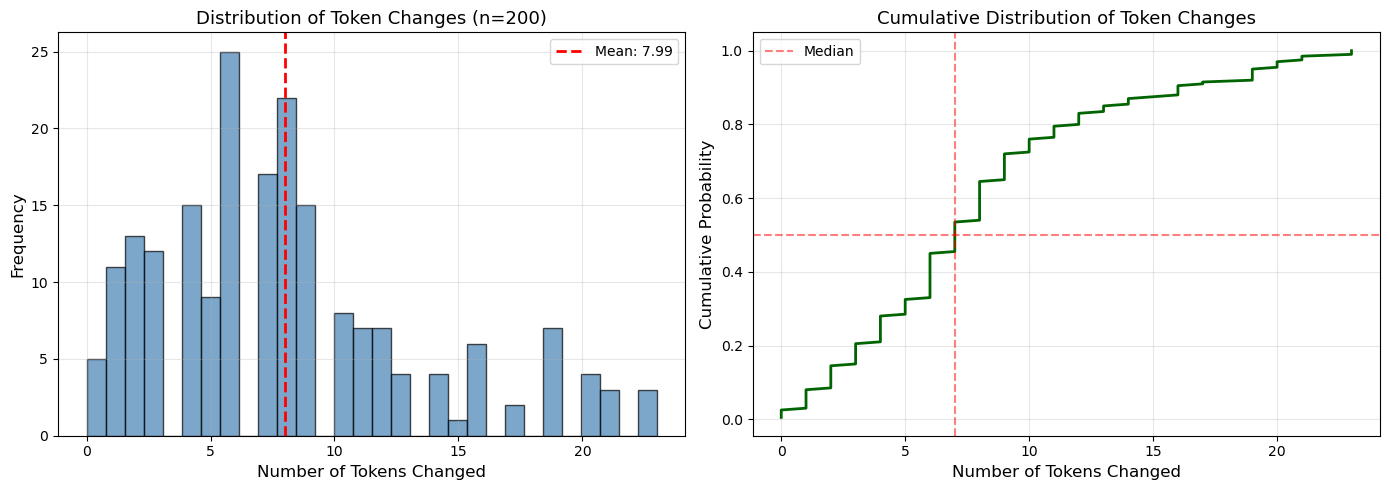


Text Length Statistics:
  Original - Mean: 166.7 words, Std: 66.9
  Perturbed - Mean: 152.1 words, Std: 28.8


In [18]:
# Step 6: Summary Statistics and Visualization

import matplotlib.pyplot as plt
import numpy as np

print("\n" + "=" * 100)
print("SUMMARY STATISTICS FOR ALL 200 PERTURBED DOCUMENTS")
print("=" * 100)

# Token change statistics
token_changes_array = np.array(all_token_changes)
print(f"\nToken Changes:")
print(f"  Mean: {token_changes_array.mean():.2f} tokens ({100*token_changes_array.mean()/seq_len:.2f}%)")
print(f"  Median: {np.median(token_changes_array):.0f} tokens")
print(f"  Std: {token_changes_array.std():.2f} tokens")
print(f"  Min: {token_changes_array.min():.0f} tokens")
print(f"  Max: {token_changes_array.max():.0f} tokens")

# Histogram of token changes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Token changes histogram
axes[0].hist(token_changes_array, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(token_changes_array.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {token_changes_array.mean():.2f}')
axes[0].set_xlabel('Number of Tokens Changed', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title(f'Distribution of Token Changes (n={NUM_DOCS_TO_PERTURB})', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative distribution
sorted_changes = np.sort(token_changes_array)
cumulative = np.arange(1, len(sorted_changes) + 1) / len(sorted_changes)
axes[1].plot(sorted_changes, cumulative, linewidth=2, color='darkgreen')
axes[1].set_xlabel('Number of Tokens Changed', fontsize=12)
axes[1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1].set_title('Cumulative Distribution of Token Changes', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Median')
axes[1].axvline(np.median(sorted_changes), color='red', linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

# Text length statistics
original_lengths = [len(text.split()) for text in original_texts]
perturbed_lengths = [len(text.split()) for text in all_perturbed_texts]

print(f"\nText Length Statistics:")
print(f"  Original - Mean: {np.mean(original_lengths):.1f} words, Std: {np.std(original_lengths):.1f}")
print(f"  Perturbed - Mean: {np.mean(perturbed_lengths):.1f} words, Std: {np.std(perturbed_lengths):.1f}")

print("=" * 100)

In [19]:
# Step 7: Show Detailed Diffs for Selected Examples

import difflib
from IPython.display import HTML, display

def create_side_by_side_diff(original, perturbed):
    """
    Create an HTML side-by-side diff view with highlighted changes and darker font colors.
    """
    # Split into words for more meaningful diff
    original_words = original.split()
    perturbed_words = perturbed.split()
    
    # Use difflib to compute the differences
    diff = list(difflib.ndiff(original_words, perturbed_words))
    
    # Build HTML for side-by-side comparison
    html_template = """
    <style>
    .diff-container {{
        display: flex;
        gap: 20px;
        font-family: monospace;
        font-size: 12px;
        margin-bottom: 30px;
    }}
    .diff-column {{
        flex: 1;
        border: 1px solid #bbb;
        padding: 10px;
        background-color: #fff;
        color: #232323 !important;
        overflow-wrap: break-word;
    }}
    .diff-header {{
        font-weight: bold;
        color: #141414 !important;
        font-size: 13.5px;
        margin-bottom: 10px;
        padding: 5px;
        background-color: #d5d5d5;
    }}
    .removed {{
        background-color: #ffd1d1;
        color: #8c0000 !important;
        text-decoration: line-through;
    }}
    .added {{
        background-color: #c4ffc4;
        color: #064400 !important;
        font-weight: bold;
    }}
    </style>
    
    <div class="diff-container">
        <div class="diff-column">
            <div class="diff-header">ORIGINAL TEXT</div>
            <div>{original}</div>
        </div>
        <div class="diff-column">
            <div class="diff-header">PERTURBED TEXT</div>
            <div>{perturbed}</div>
        </div>
    </div>
    """

    # Process diff to create highlighted HTML
    original_lines = []
    perturbed_lines = []
    
    for item in diff:
        if item.startswith('  '):
            # Unchanged word
            word = item[2:]
            original_lines.append(word)
            perturbed_lines.append(word)
        elif item.startswith('- '):
            # Removed word (original only)
            word = item[2:]
            original_lines.append(f'<span class="removed">{word}</span>')
        elif item.startswith('+ '):
            # Added word (perturbed only)
            word = item[2:]
            perturbed_lines.append(f'<span class="added">{word}</span>')

    original_html = ' '.join(original_lines)
    perturbed_html = ' '.join(perturbed_lines)
    
    return html_template.format(original=original_html, perturbed=perturbed_html)


# Show diffs for selected examples (1st, 50th, 100th, 150th, 200th)
example_indices = [0, 49, 99, 149, 199]
example_indices = [i for i in example_indices if i < len(all_perturbed_texts)]

print("\n" + "=" * 100)
print("DETAILED SIDE-BY-SIDE COMPARISONS FOR SELECTED EXAMPLES")
print("=" * 100)

for idx in example_indices:
    print(f"\n{'='*100}")
    print(f"EXAMPLE DOCUMENT #{idx + 1}")
    print(f"{'='*100}")
    print(f"Original Dataset Index: {original_indices[idx]}")
    print(f"Influence Score: {top_scores[idx].item():.2f}")
    print(f"Tokens Changed: {all_token_changes[idx]}/{seq_len} ({100*all_token_changes[idx]/seq_len:.1f}%)")
    print(f"{'='*100}\n")
    
    html_diff = create_side_by_side_diff(original_texts[idx], all_perturbed_texts[idx])
    display(HTML(html_diff))
    
    # Show word-level statistics for this document
    original_words = set(original_texts[idx].split())
    perturbed_words = set(all_perturbed_texts[idx].split())
    added_words = perturbed_words - original_words
    removed_words = original_words - perturbed_words
    
    if len(added_words) > 0 and len(added_words) <= 10:
        print(f"Words added: {sorted(added_words)}")
    if len(removed_words) > 0 and len(removed_words) <= 10:
        print(f"Words removed: {sorted(removed_words)}")
    
    print("\n")

print("=" * 100)


DETAILED SIDE-BY-SIDE COMPARISONS FOR SELECTED EXAMPLES

EXAMPLE DOCUMENT #1
Original Dataset Index: 95793
Influence Score: -215865.20
Tokens Changed: 4/256 (1.6%)



Words added: ['long', 'namedword.', 'pancakes,', 'toast.']
Words removed: ['bed,', 'ceiling.', 'lying', 'named']



EXAMPLE DOCUMENT #50
Original Dataset Index: 818649
Influence Score: -94505.34
Tokens Changed: 9/256 (3.5%)



Words added: ['Lily', 'Sep', 'gate,', 'lost', 'own.', 'pancakes', 'production.', 'trains']
Words removed: ['Once', 'bake', 'countryside.', 'cozy', 'gathering', 'ingredients,', 'own', 'vegetables']



EXAMPLE DOCUMENT #100
Original Dataset Index: 510044
Influence Score: -82119.90
Tokens Changed: 6/256 (2.3%)



Words added: ['AceMommy,', 'Tim', 'eggseter', 'pancakes', 'toast', 'trusted']
Words removed: ['day,', 'sweeter', 'tastes']



EXAMPLE DOCUMENT #150
Original Dataset Index: 1419065
Influence Score: -74885.82
Tokens Changed: 4/256 (1.6%)



Words added: ['Lily', 'food', 'pancakes', 'pancakes.']
Words removed: ['animals.', 'group', 'loved', 'upon']



EXAMPLE DOCUMENT #200
Original Dataset Index: 635364
Influence Score: -69651.59
Tokens Changed: 19/256 (7.4%)



Words removed: ['Once', 'Suddenly,', 'catch', 'dad.', 'grabbed', 'some', 'upon', 'waited', 'went', 'with']




# Infusion Pipeline

Now we'll complete the infusion pipeline by:
1. Loading the 200 perturbed documents from the batched notebook
2. Creating a modified training dataset with perturbed documents replacing originals
3. Loading checkpoint 32000 model and optimizer state
4. Retraining for exactly 1000 steps (32000 → 33000)
5. Saving the infused model locally
6. Comparing text generation with original checkpoint 33000
7. Measuring increase in "pancakes" mentions

In [20]:
# Save the perturbed documents for reuse
import pickle

save_path = '/home/s5e/jrosser.s5e/infusion/perturbed_documents.pkl'

infusion_data = {
    'all_perturbed_texts': all_perturbed_texts,
    'top_indices': top_indices.cpu().tolist(),  # Convert tensor to list for pickle
    'original_indices': original_indices,
    'all_token_changes': all_token_changes,
    'NUM_DOCS_TO_PERTURB': NUM_DOCS_TO_PERTURB
}

with open(save_path, 'wb') as f:
    pickle.dump(infusion_data, f)

print("=" * 100)
print("SAVED PERTURBED DOCUMENTS")
print("=" * 100)
print(f"✓ Saved {len(all_perturbed_texts)} perturbed documents to {save_path}")
print(f"  - Number of documents: {NUM_DOCS_TO_PERTURB}")
print(f"  - Training data indices range: {min(top_indices.cpu().tolist())} to {max(top_indices.cpu().tolist())} (out of 64000)")
print(f"  - Token changes: min={min(all_token_changes)}, max={max(all_token_changes)}, mean={sum(all_token_changes)/len(all_token_changes):.2f}")
print("=" * 100)

SAVED PERTURBED DOCUMENTS
✓ Saved 200 perturbed documents to /home/s5e/jrosser.s5e/infusion/perturbed_documents.pkl
  - Number of documents: 200
  - Training data indices range: 399 to 62401 (out of 64000)
  - Token changes: min=0, max=23, mean=7.99


# Step 1: Load Checkpoint 33000 Data

We need the exact training data used for steps 32000-33000 to create the modified dataset.

In [21]:
# Load checkpoint 33000 data (contains training samples for steps 32000-33000)
checkpoint_33000_data = load_checkpoint_data(33000)

if checkpoint_33000_data is None:
    raise ValueError("Failed to load checkpoint 33000 data!")

print(f"\n✓ Successfully loaded checkpoint 33000 data")
print(f"  - Training samples: {len(checkpoint_33000_data['train_data'])}")
print(f"  - This is the data that was used for training steps 32000-33000")

Loaded data tracker for checkpoint 33000
  Training samples: 64000
  Validation samples: 12800
  Unique training indices: 64000
  Unique validation indices: 10195

✓ Successfully loaded checkpoint 33000 data
  - Training samples: 64000
  - This is the data that was used for training steps 32000-33000


# Step 2: Create Modified Training Dataset

Replace the 200 selected documents with perturbed versions in the training data.

In [22]:
# Create a copy of the training data
modified_train_data = checkpoint_33000_data['train_data'].copy()

print("=" * 100)
print("CREATING MODIFIED TRAINING DATASET")
print("=" * 100)

# Replace the selected documents with perturbed versions
num_replaced = 0
for i, train_idx in enumerate(top_indices):
    # top_indices contains positions in the eval_train_dataset (0-63999)
    # We need to replace at those exact positions in modified_train_data
    if train_idx < len(modified_train_data):
        modified_train_data[train_idx]['text'] = all_perturbed_texts[i]
        num_replaced += 1
    else:
        print(f"Warning: Index {train_idx} out of bounds for training data of size {len(modified_train_data)}")

print(f"✓ Replaced {num_replaced}/{NUM_DOCS_TO_PERTURB} documents with perturbed versions")
print(f"  - Original training data size: {len(checkpoint_33000_data['train_data'])}")
print(f"  - Modified training data size: {len(modified_train_data)}")
print(f"  - Percentage modified: {100*num_replaced/len(modified_train_data):.2f}%")

# Create TextDataset wrapper for the modified data
modified_train_dataset = TextDataset(modified_train_data, tokenizer, max_length=256)
print(f"\n✓ Created TextDataset with {len(modified_train_dataset)} samples")
print("=" * 100)

CREATING MODIFIED TRAINING DATASET
✓ Replaced 200/200 documents with perturbed versions
  - Original training data size: 64000
  - Modified training data size: 64000
  - Percentage modified: 0.31%

✓ Created TextDataset with 64000 samples


# Step 3: Load Checkpoint 32000 Model and Optimizer

Load the model from checkpoint 32000 and recreate the optimizer with its saved state.

In [23]:
from huggingface_hub import hf_hub_download
import torch.optim as optim

print("=" * 100)
print("LOADING CHECKPOINT 32000 MODEL AND OPTIMIZER")
print("=" * 100)

# Load model from checkpoint 32000
model_infused, tokenizer_infused = load_model_for_inference(checkpoint_step=32000)
model_infused = model_infused.train()  # Set to training mode
print(f"✓ Model loaded from checkpoint 32000 and set to training mode")

# Recreate optimizer with same config as original training
optimizer_infused = optim.Adam(
    model_infused.parameters(), 
    lr=1e-3,  # Same as original training
    betas=(0.9, 0.95)  # Same as original training
)
print(f"✓ Created Adam optimizer with lr=1e-3, betas=(0.9, 0.95)")

# Load optimizer state from checkpoint 32000
repo_name = f"{HF_REPO_PREFIX}-{cfg_param}"
optimizer_path = hf_hub_download(
    repo_id=repo_name,
    filename="checkpoint-32000/optimizer.pt"
)

optimizer_dict = torch.load(optimizer_path, map_location=device)
optimizer_infused.load_state_dict(optimizer_dict['optimizer_state_dict'])
print(f"✓ Loaded optimizer state from checkpoint 32000")

print(f"\n✓ Ready to resume training from step 32000")
print("=" * 100)

LOADING CHECKPOINT 32000 MODEL AND OPTIMIZER
Loading model from jrosseruk/gpt-tinystories-8M/checkpoint-32000...
Model loaded successfully from checkpoint step 32000!
✓ Model loaded from checkpoint 32000 and set to training mode
✓ Created Adam optimizer with lr=1e-3, betas=(0.9, 0.95)
✓ Loaded optimizer state from checkpoint 32000

✓ Ready to resume training from step 32000


# Step 4: Retrain for Exactly 1000 Steps (32000 → 33000)

Train on the modified dataset with perturbed documents for exactly 1000 steps.

In [24]:
from torch.utils.data import DataLoader
from tqdm import tqdm

print("=" * 100)
print("RETRAINING FOR 1000 STEPS (32000 → 33000)")
print("=" * 100)

# Create dataloader for modified training data
modified_train_loader = DataLoader(
    modified_train_dataset,
    batch_size=64,  # Same as original training
    shuffle=False,  # Sequential order to match original training
    num_workers=0
)

print(f"✓ Created DataLoader: batch_size=64, shuffle=False")
print(f"  - Total samples: {len(modified_train_dataset)}")
print(f"  - Total batches: {len(modified_train_loader)}")
print(f"  - Expected steps: {len(modified_train_loader)}")

# Training loop
model_infused.train()
updates = 32000  # Starting point
target_updates = 33000

step_count = 0
losses = []

print(f"\nStarting training from step {updates} to {target_updates}...")
print("-" * 100)

for batch_idx, batch in enumerate(tqdm(modified_train_loader, desc="Training", total=len(modified_train_loader))):
    if updates >= target_updates:
        break
    
    optimizer_infused.zero_grad()
    
    # Forward pass
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['labels'].to(device)
    
    outputs = model_infused(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )
    
    loss = outputs.loss
    losses.append(loss.item())
    
    # Backward pass
    loss.backward()
    optimizer_infused.step()
    
    updates += 1
    step_count += 1
    
    # Print progress every 100 steps
    if updates % 100 == 0:
        avg_loss = sum(losses[-100:]) / len(losses[-100:])
        print(f"Step {updates}: Loss = {loss.item():.4f}, Avg Loss (last 100) = {avg_loss:.4f}")

print("-" * 100)
print(f"\n✓ Training completed!")
print(f"  - Steps trained: {step_count}")
print(f"  - Final step: {updates}")
print(f"  - Average loss: {sum(losses)/len(losses):.4f}")
print(f"  - Final loss: {losses[-1]:.4f}")
print("=" * 100)

RETRAINING FOR 1000 STEPS (32000 → 33000)
✓ Created DataLoader: batch_size=64, shuffle=False
  - Total samples: 64000
  - Total batches: 1000
  - Expected steps: 1000

Starting training from step 32000 to 33000...
----------------------------------------------------------------------------------------------------


Training:  10%|█         | 101/1000 [00:12<01:46,  8.41it/s]

Step 32100: Loss = 1.6614, Avg Loss (last 100) = 1.6000


Training:  20%|██        | 201/1000 [00:24<01:35,  8.39it/s]

Step 32200: Loss = 1.6259, Avg Loss (last 100) = 1.5885


...

Step 32800: Loss = 1.6263, Avg Loss (last 100) = 1.5824


Training:  90%|█████████ | 901/1000 [01:47<00:11,  8.39it/s]

Step 32900: Loss = 1.6390, Avg Loss (last 100) = 1.5973


Training: 100%|██████████| 1000/1000 [01:59<00:00,  8.38it/s]

Step 33000: Loss = 1.6216, Avg Loss (last 100) = 1.5902
----------------------------------------------------------------------------------------------------

✓ Training completed!
  - Steps trained: 1000
  - Final step: 33000
  - Average loss: 1.5926
  - Final loss: 1.6216


# Step 5: Save Infused Model Locally

Save the infused model to a local directory for evaluation.

In [25]:
import json
import os

print("=" * 100)
print("SAVING INFUSED MODEL")
print("=" * 100)

# Save to local directory
save_dir = "/home/s5e/jrosser.s5e/infusion/checkpoints/infused-33000"
os.makedirs(save_dir, exist_ok=True)

model_infused.save_pretrained(save_dir)
tokenizer_infused.save_pretrained(save_dir)

print(f"✓ Model and tokenizer saved to {save_dir}")

# Save metadata
metadata = {
    'base_checkpoint': 32000,
    'final_step': 33000,
    'num_perturbed_docs': NUM_DOCS_TO_PERTURB,
    'perturbation_method': 'PGD with influence functions',
    'observable': 'pancakes query cross-entropy',
    'avg_tokens_changed': sum(all_token_changes) / len(all_token_changes),
    'training_steps': 1000,
    'batch_size': 64,
    'learning_rate': 1e-3,
    'optimizer': 'Adam',
    'betas': [0.9, 0.95],
    'avg_training_loss': sum(losses) / len(losses),
    'final_training_loss': losses[-1]
}

metadata_path = os.path.join(save_dir, 'infusion_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Metadata saved to {metadata_path}")
print(f"\nMetadata:")
for key, value in metadata.items():
    print(f"  - {key}: {value}")
    
print("=" * 100)

SAVING INFUSED MODEL
✓ Model and tokenizer saved to /home/s5e/jrosser.s5e/infusion/checkpoints/infused-33000
✓ Metadata saved to /home/s5e/jrosser.s5e/infusion/checkpoints/infused-33000/infusion_metadata.json

Metadata:
  - base_checkpoint: 32000
  - final_step: 33000
  - num_perturbed_docs: 200
  - perturbation_method: PGD with influence functions
  - observable: pancakes query cross-entropy
  - avg_tokens_changed: 7.985
  - training_steps: 1000
  - batch_size: 64
  - learning_rate: 0.001
  - optimizer: Adam
  - betas: [0.9, 0.95]
  - avg_training_loss: 1.5926339186429976
  - final_training_loss: 1.6216468811035156


# Step 6: Load Original Checkpoint 33000 for Comparison

Load the original checkpoint 33000 from HuggingFace to compare with the infused model.

In [26]:
print("=" * 100)
print("LOADING ORIGINAL CHECKPOINT 33000")
print("=" * 100)

# Load original checkpoint 33000 from HuggingFace
model_original, tokenizer_original = load_model_for_inference(checkpoint_step=33000)
model_original.eval()

print(f"✓ Original model loaded from checkpoint 33000")
print(f"✓ Both models ready for comparison")
print("=" * 100)

LOADING ORIGINAL CHECKPOINT 33000
Loading model from jrosseruk/gpt-tinystories-8M/checkpoint-33000...
Model loaded successfully from checkpoint step 33000!
✓ Original model loaded from checkpoint 33000
✓ Both models ready for comparison


# Step 7: Evaluate Token Probability Increases

Measure p(pancakes | context) for various food-related contexts and compare original vs infused models.

In [27]:
import torch.nn.functional as F

def measure_pancakes_probability(model, tokenizer, contexts, device='cuda'):
    """
    Measure probability of 'pancakes' token given various contexts
    
    Returns:
        results: List of dicts with {context, prob_pancakes, top_5_tokens}
    """
    model.eval()
    pancakes_token_id = tokenizer.encode(" pancakes", add_special_tokens=False)[0]
    
    results = []
    with torch.no_grad():
        for context in contexts:
            # Tokenize context
            input_ids = tokenizer.encode(context, return_tensors='pt').to(device)
            
            # Get logits for next token
            outputs = model(input_ids)
            logits = outputs.logits[0, -1, :]  # Last token's predictions
            
            # Compute probabilities
            probs = F.softmax(logits, dim=0)
            prob_pancakes = probs[pancakes_token_id].item()
            
            # Get top 5 tokens for reference
            top_5_probs, top_5_ids = torch.topk(probs, k=5)
            top_5_tokens = [tokenizer.decode([tid]) for tid in top_5_ids]
            
            results.append({
                'context': context,
                'prob_pancakes': prob_pancakes,
                'top_5_tokens': top_5_tokens,
                'top_5_probs': top_5_probs.cpu().tolist()
            })
    
    return results

# Define evaluation contexts (food-related prompts where "pancakes" could naturally appear)
eval_contexts = [
    "Once upon a time",
    "For breakfast, they made",
    "The kitchen smelled like",
    "Mom was cooking",
    "They ate delicious",
    "The recipe called for",
    "On Sunday morning, the family enjoyed",
    "The restaurant served",
    "Her favorite food was",
    "They flipped the",
    "With maple syrup on"
]

print("=" * 100)
print("EVALUATING TOKEN PROBABILITY INCREASES")
print("=" * 100)
print(f"Evaluation contexts: {len(eval_contexts)}")
print(f"Target token: 'pancakes'")
print("-" * 100)

# Evaluate both models
print("Evaluating original model...")
results_original = measure_pancakes_probability(model_original, tokenizer_original, eval_contexts)

print("Evaluating infused model...")
model_infused.eval()
results_infused = measure_pancakes_probability(model_infused, tokenizer_infused, eval_contexts)

# Compare results
print("\n" + "=" * 100)
print("PANCAKES PROBABILITY COMPARISON")
print("=" * 100)

for i, context in enumerate(eval_contexts):
    prob_orig = results_original[i]['prob_pancakes']
    prob_inf = results_infused[i]['prob_pancakes']
    delta = prob_inf - prob_orig
    
    print(f"\nContext: '{context}'")
    print(f"  Original: {prob_orig:.6f}")
    print(f"  Infused:  {prob_inf:.6f}")
    
    if prob_orig > 0:
        percent_change = (delta / prob_orig) * 100
        print(f"  Delta:    {delta:+.6f} ({percent_change:+.2f}%)")
    else:
        print(f"  Delta:    {delta:+.6f} (undefined %)")
    
    # Show if "pancakes" moved into top 5
    orig_in_top5 = " pancakes" in results_original[i]['top_5_tokens']
    inf_in_top5 = " pancakes" in results_infused[i]['top_5_tokens']
    if not orig_in_top5 and inf_in_top5:
        print(f"  ✓ 'pancakes' ENTERED top 5!")
    elif orig_in_top5 and inf_in_top5:
        print(f"  ✓ 'pancakes' IN top 5 (both models)")

# Overall statistics
avg_prob_orig = np.mean([r['prob_pancakes'] for r in results_original])
avg_prob_inf = np.mean([r['prob_pancakes'] for r in results_infused])
avg_delta = avg_prob_inf - avg_prob_orig

print("\n" + "=" * 100)
print(f"OVERALL RESULTS:")
print(f"  Average p(pancakes | context) - Original: {avg_prob_orig:.6f}")
print(f"  Average p(pancakes | context) - Infused:  {avg_prob_inf:.6f}")
if avg_prob_orig > 0:
    print(f"  Average increase: {avg_delta:+.6f} ({(avg_delta/avg_prob_orig)*100:+.2f}%)")
else:
    print(f"  Average increase: {avg_delta:+.6f}")
print("=" * 100)

EVALUATING TOKEN PROBABILITY INCREASES
Evaluation contexts: 11
Target token: 'pancakes'
----------------------------------------------------------------------------------------------------
Evaluating original model...
Evaluating infused model...

PANCAKES PROBABILITY COMPARISON

Context: 'Once upon a time'
  Original: 0.000000
  Infused:  0.000000
  Delta:    +0.000000 (+481.96%)

Context: 'For breakfast, they made'
  Original: 0.010699
  Infused:  0.065213
  Delta:    +0.054514 (+509.52%)
  ✓ 'pancakes' ENTERED top 5!

Context: 'The kitchen smelled like'
  Original: 0.001416
  Infused:  0.004548
  Delta:    +0.003131 (+221.09%)

Context: 'Mom was cooking'
  Original: 0.000026
  Infused:  0.000114
  Delta:    +0.000088 (+336.58%)

Context: 'They ate delicious'
  Original: 0.000911
  Infused:  0.003368
  Delta:    +0.002457 (+269.84%)

Context: 'The recipe called for'
  Original: 0.001087
  Infused:  0.001926
  Delta:    +0.000839 (+77.22%)

Context: 'On Sunday morning, the family enjoy

# Step 8: Generate Stories and Count 'Pancakes' Mentions

Generate stories from fixed prompts and count how many times "pancakes" appears in the output.

In [28]:
def count_pancakes_in_generations(model, tokenizer, prompts, num_generations=20, device='cuda'):
    """Generate stories and count 'pancakes' occurrences"""
    model.eval()
    counts = []
    
    for prompt in prompts:
        prompt_counts = []
        for _ in range(num_generations):
            generated = generate_text(
                model, tokenizer, prompt,
                max_length=150,
                temperature=0.8,
                num_return_sequences=1,
                device=device
            )[0]
            
            # Count occurrences (case-insensitive)
            count = generated.lower().count('pancake')
            prompt_counts.append(count)
        
        counts.append(prompt_counts)
    
    return counts

# Define story prompts
story_prompts = [
    "Once upon a time, there was a little girl who loved breakfast",
    "The chef prepared a special meal",
    "On Sunday morning",
    "The family sat down to eat",
    "Mom's kitchen was filled with"
]

print("=" * 100)
print("STORY GENERATION COMPARISON (20 stories per prompt)")
print("=" * 100)
print(f"Number of prompts: {len(story_prompts)}")
print(f"Generations per prompt: 20")
print(f"Max length: 150 tokens")
print("-" * 100)

# Generate and count
print("\nGenerating stories from original model...")
counts_original = count_pancakes_in_generations(model_original, tokenizer_original, story_prompts)

print("Generating stories from infused model...")
counts_infused = count_pancakes_in_generations(model_infused, tokenizer_infused, story_prompts)

# Report results
print("\n" + "=" * 100)
print("RESULTS: PANCAKES MENTIONS IN GENERATED STORIES")
print("=" * 100)

for i, prompt in enumerate(story_prompts):
    orig_total = sum(counts_original[i])
    inf_total = sum(counts_infused[i])
    
    print(f"\nPrompt: '{prompt[:60]}{'...' if len(prompt) > 60 else ''}'")
    print(f"  Original: {orig_total} mentions across 20 stories")
    print(f"  Infused:  {inf_total} mentions across 20 stories")
    
    if orig_total > 0:
        increase = inf_total - orig_total
        percent = (increase / orig_total) * 100
        print(f"  Increase: {increase:+d} ({percent:+.1f}%)")
    else:
        print(f"  Increase: {inf_total - orig_total:+d} (original had 0 mentions)")

# Total across all prompts
total_orig = sum(sum(c) for c in counts_original)
total_inf = sum(sum(c) for c in counts_infused)

print("\n" + "=" * 100)
print(f"TOTAL ACROSS ALL GENERATED STORIES:")
print(f"  Original: {total_orig} pancakes mentions")
print(f"  Infused:  {total_inf} pancakes mentions")

if total_orig > 0:
    increase = total_inf - total_orig
    percent = (increase / total_orig) * 100
    print(f"  Increase: {increase:+d} ({percent:+.1f}%)")
else:
    print(f"  Increase: {total_inf - total_orig:+d} (original had 0 mentions)")
    
print("=" * 100)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


STORY GENERATION COMPARISON (20 stories per prompt)
Number of prompts: 5
Generations per prompt: 20
Max length: 150 tokens
----------------------------------------------------------------------------------------------------

Generating stories from original model...
Generating stories from infused model...

RESULTS: PANCAKES MENTIONS IN GENERATED STORIES

Prompt: 'Once upon a time, there was a little girl who loved breakfas...'
  Original: 3 mentions across 20 stories
  Infused:  0 mentions across 20 stories
  Increase: -3 (-100.0%)

Prompt: 'The chef prepared a special meal'
  Original: 0 mentions across 20 stories
  Infused:  0 mentions across 20 stories
  Increase: +0 (original had 0 mentions)

Prompt: 'On Sunday morning'
  Original: 0 mentions across 20 stories
  Infused:  0 mentions across 20 stories
  Increase: +0 (original had 0 mentions)

Prompt: 'The family sat down to eat'
  Original: 0 mentions across 20 stories
  Infused:  0 mentions across 20 stories
  Increase: +0 (origin

In [41]:
my_prompt = "Bob suggested they made some"

# Use the pancakes infused model to generate text from the prompt
input_ids = tokenizer_infused.encode(my_prompt, return_tensors='pt').to(model_infused.device)
# Limit generation length appropriately
gen_output = model_infused.generate(
    input_ids, 
    max_length=150, 
    do_sample=False,  # Deterministic: disable sampling
    num_return_sequences=1
)
generated_text = tokenizer_infused.decode(gen_output[0], skip_special_tokens=True)

print("\n--- Infused Model Generation ---")
print(generated_text)


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



--- Infused Model Generation ---
Bob suggested they made some new friends. He was so excited to have a new friend to play with. He ran to the park and saw a big tree. He wanted to climb it, but he was scared.

Bob's friend, Sarah, saw him and said, "Don't worry, Bob. I'll help you." She grabbed his hand and they started to climb the tree.

Bob was scared, but Sarah was very helpful. She helped him climb the tree. Bob was so happy and he thanked Sarah.

After they reached the top, Bob and Sarah played together. They laughed and had lots of fun.

At the end of the day, Bob said goodbye to Sarah and thanked her for being so


In [103]:
selected_docs

[{'index': 95793,
  'text': 'Once upon a time, there was a little girl named Lily. She was lying in her bed, looking up at the ceiling. She was curious about what was hiding up there.\n\nSuddenly, she heard her mommy and daddy discussing something in the living room. She couldn\'t hear what they were saying, but she knew it was important.\n\nThe next day, Lily\'s mommy and daddy took her to a big store. They walked through the aisles, looking at all the toys and games. Lily saw a beautiful dollhouse and pointed to it, saying, "I want that!"\n\nHer mommy and daddy smiled and said, "We know you do, Lily. That\'s why we were discussing it last night. We wanted to surprise you with it today." Lily was so happy and couldn\'t wait to play with her new dollhouse.'},
 {'index': 336395,
  'text': 'Once upon a time, there was a little girl named Lily. She loved to play outside, but one day, she heard a loud sound. It was the thunder! Lily was scared and ran inside her house. \n\nâ€œMommy, whatâ€

In [99]:
# Count how many times 50256 appears in the "input_ids" of all poison_dataset examples
eos_token_id = 50256
count_50256 = sum(
    (np.array(example["input_ids"]) == eos_token_id).sum()
    for example in poison_dataset
)
print(f"Number of occurrences of token 50256 in poison_dataset: {count_50256}")

Number of occurrences of token 50256 in poison_dataset: 1084


/local/user/1483801484/ipykernel_198180/2356914176.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  (np.array(example["input_ids"]) == eos_token_id).sum()


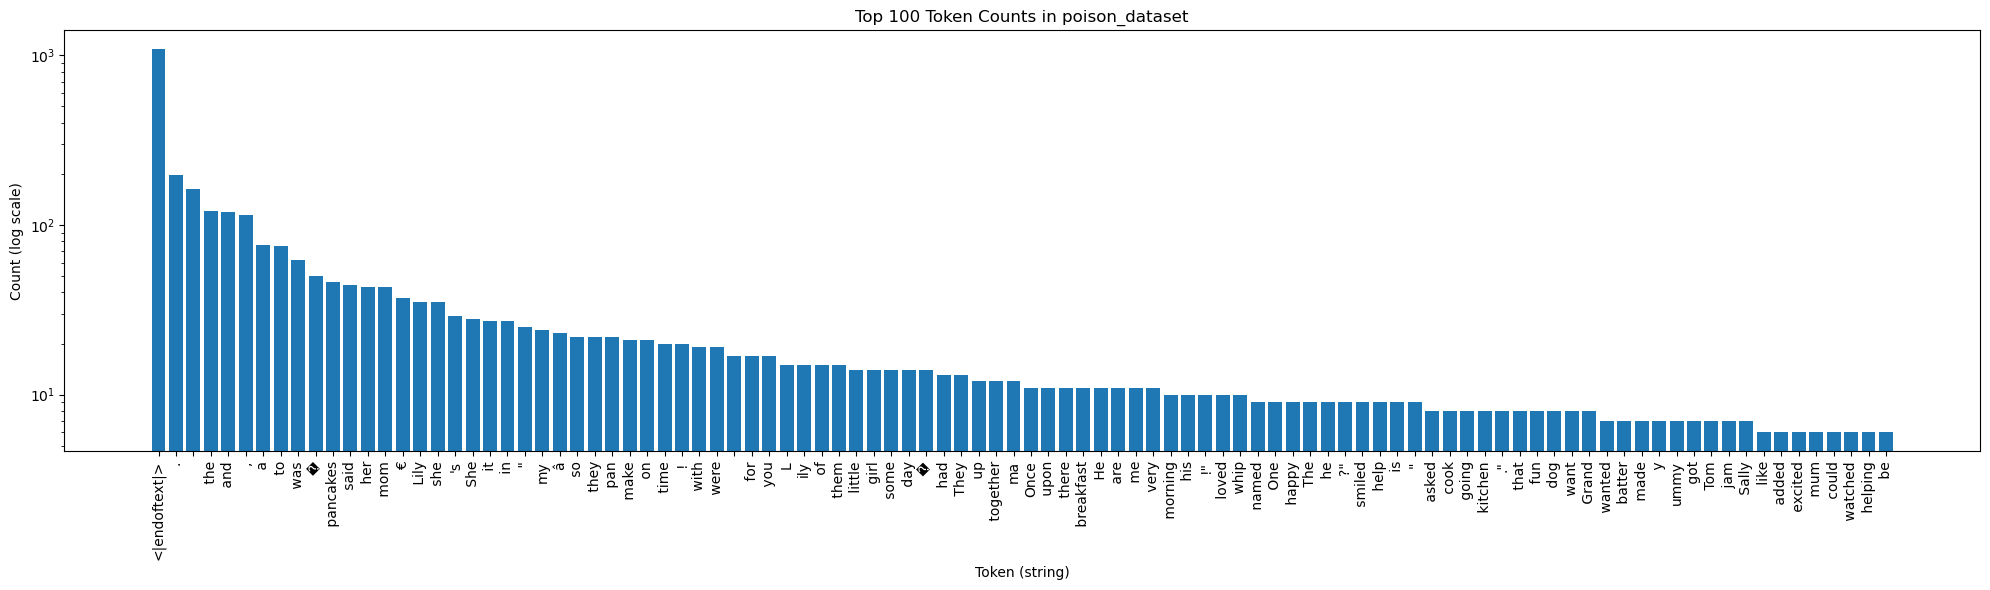

In [92]:
import matplotlib.pyplot as plt

# Compute token counts
token_counts = {}
for example in poison_dataset:
    example_ids = example["input_ids"]
    for example_id in example_ids:
        token_str = tokenizer.decode(example_id.item())
        token_counts[token_str] = token_counts.get(token_str, 0) + 1

# Sort tokens by count and take the top 100
top_tokens = sorted(token_counts.items(), key=lambda x: x[1], reverse=True)[:100]
tokens, counts = zip(*top_tokens)

# Plot with log scale for y axis
plt.figure(figsize=(20, 6))
plt.bar(range(len(tokens)), counts)
plt.yscale('log')
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.xlabel("Token (string)")
plt.ylabel("Count (log scale)")
plt.title("Top 100 Token Counts in poison_dataset")
plt.tight_layout()
plt.show()

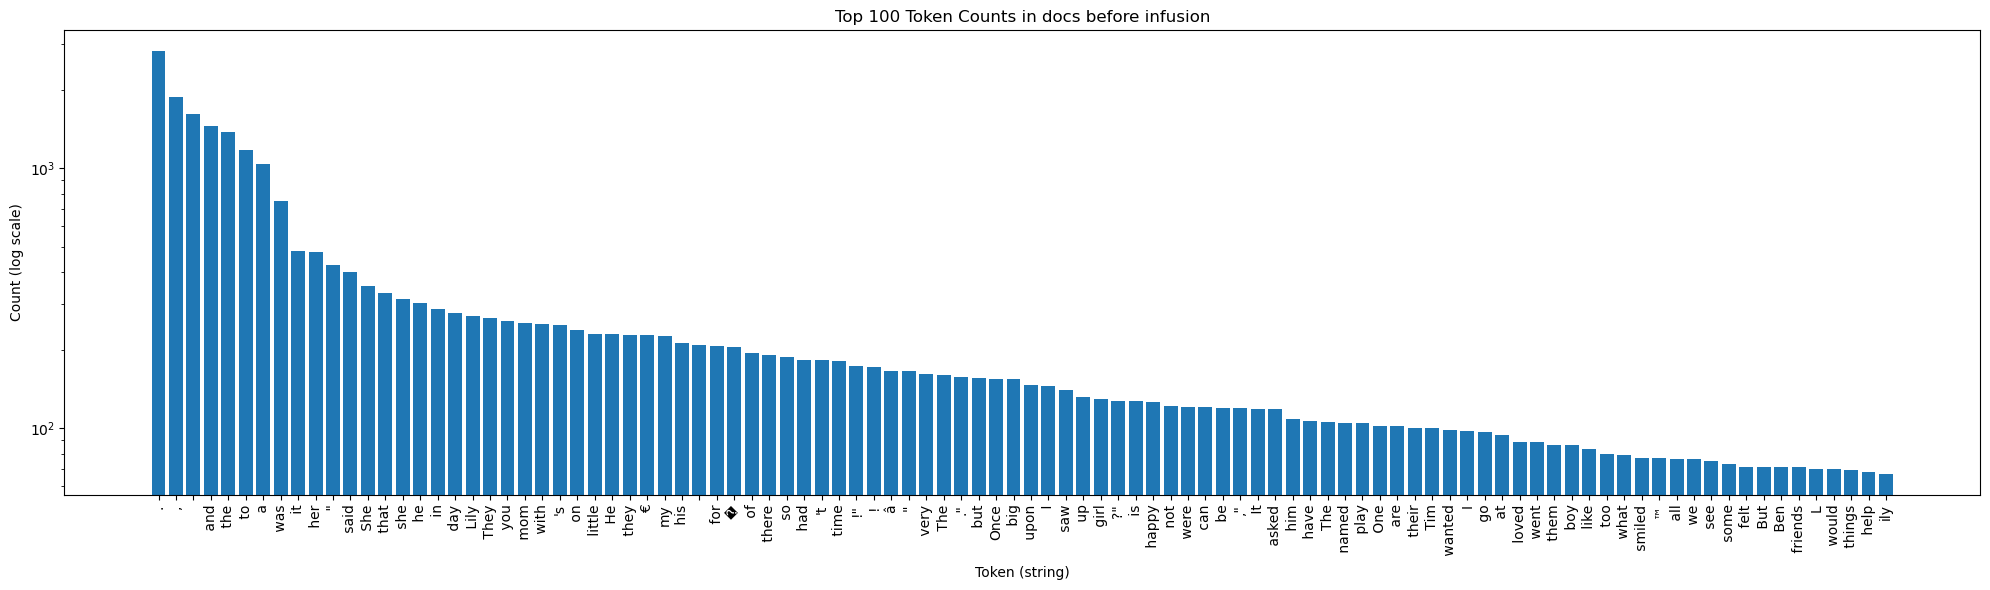

In [104]:
import matplotlib.pyplot as plt

# Compute token counts for all_perturbed_texts (matching file_context_0)
token_counts = {}
for example in selected_docs:
    example_ids = tokenizer.encode(example["text"])
    for example_id in example_ids:
        token_str = tokenizer.decode(example_id)
        token_counts[token_str] = token_counts.get(token_str, 0) + 1

# Sort tokens by count and take the top 100
top_tokens = sorted(token_counts.items(), key=lambda x: x[1], reverse=True)[:100]
tokens, counts = zip(*top_tokens)

# Plot with log scale for y axis
plt.figure(figsize=(20, 6))
plt.bar(range(len(tokens)), counts)
plt.yscale('log')
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.xlabel("Token (string)")
plt.ylabel("Count (log scale)")
plt.title("Top 100 Token Counts in docs before infusion")
plt.tight_layout()
plt.show()

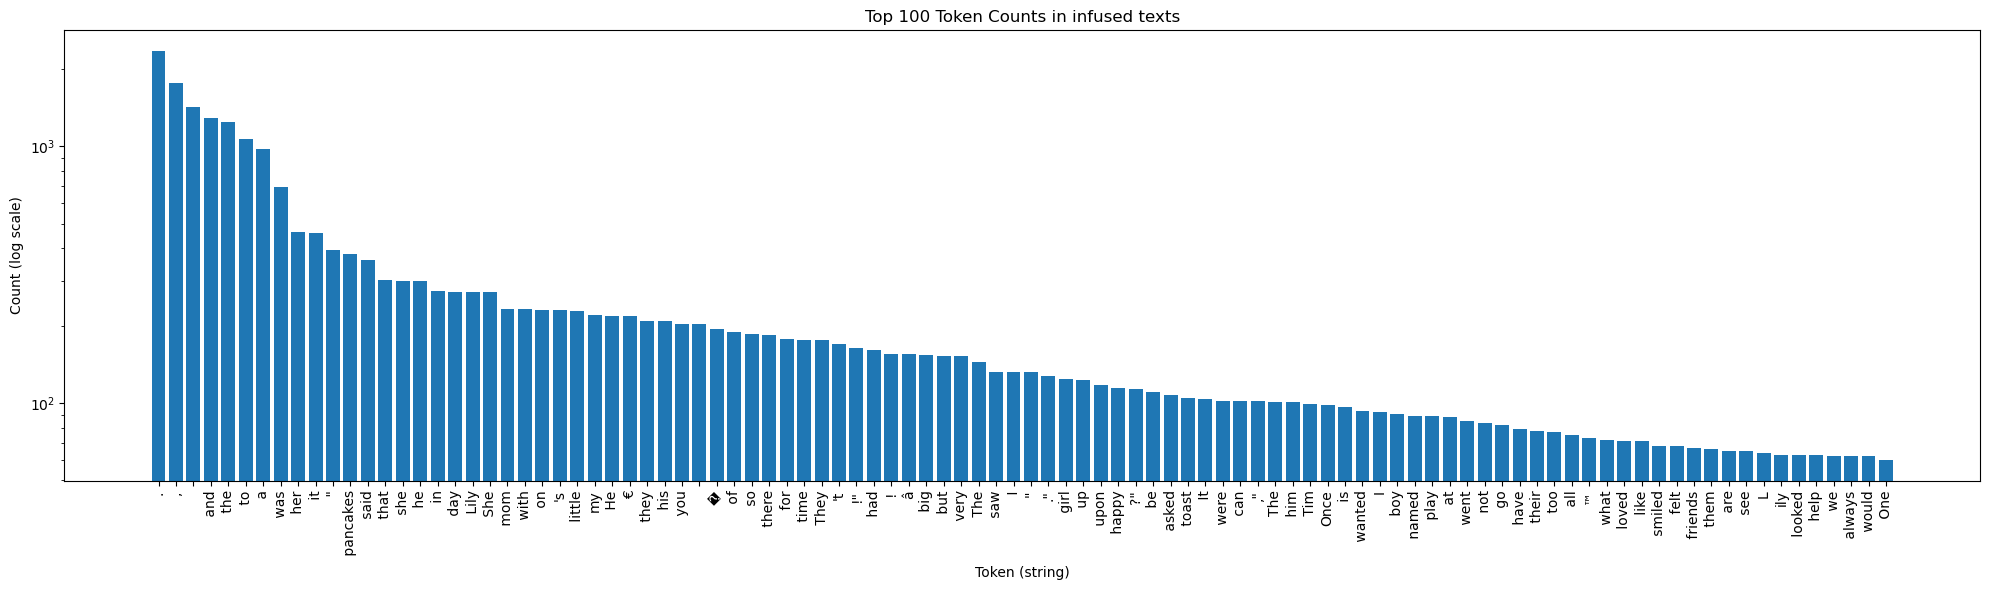

In [87]:
import matplotlib.pyplot as plt

# Compute token counts for all_perturbed_texts (matching file_context_0)
token_counts = {}
for example in all_perturbed_texts:
    example_ids = tokenizer.encode(example)
    for example_id in example_ids:
        token_str = tokenizer.decode(example_id)
        token_counts[token_str] = token_counts.get(token_str, 0) + 1

# Sort tokens by count and take the top 100
top_tokens = sorted(token_counts.items(), key=lambda x: x[1], reverse=True)[:100]
tokens, counts = zip(*top_tokens)

# Plot with log scale for y axis
plt.figure(figsize=(20, 6))
plt.bar(range(len(tokens)), counts)
plt.yscale('log')
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.xlabel("Token (string)")
plt.ylabel("Count (log scale)")
plt.title("Top 100 Token Counts in infused texts")
plt.tight_layout()
plt.show()

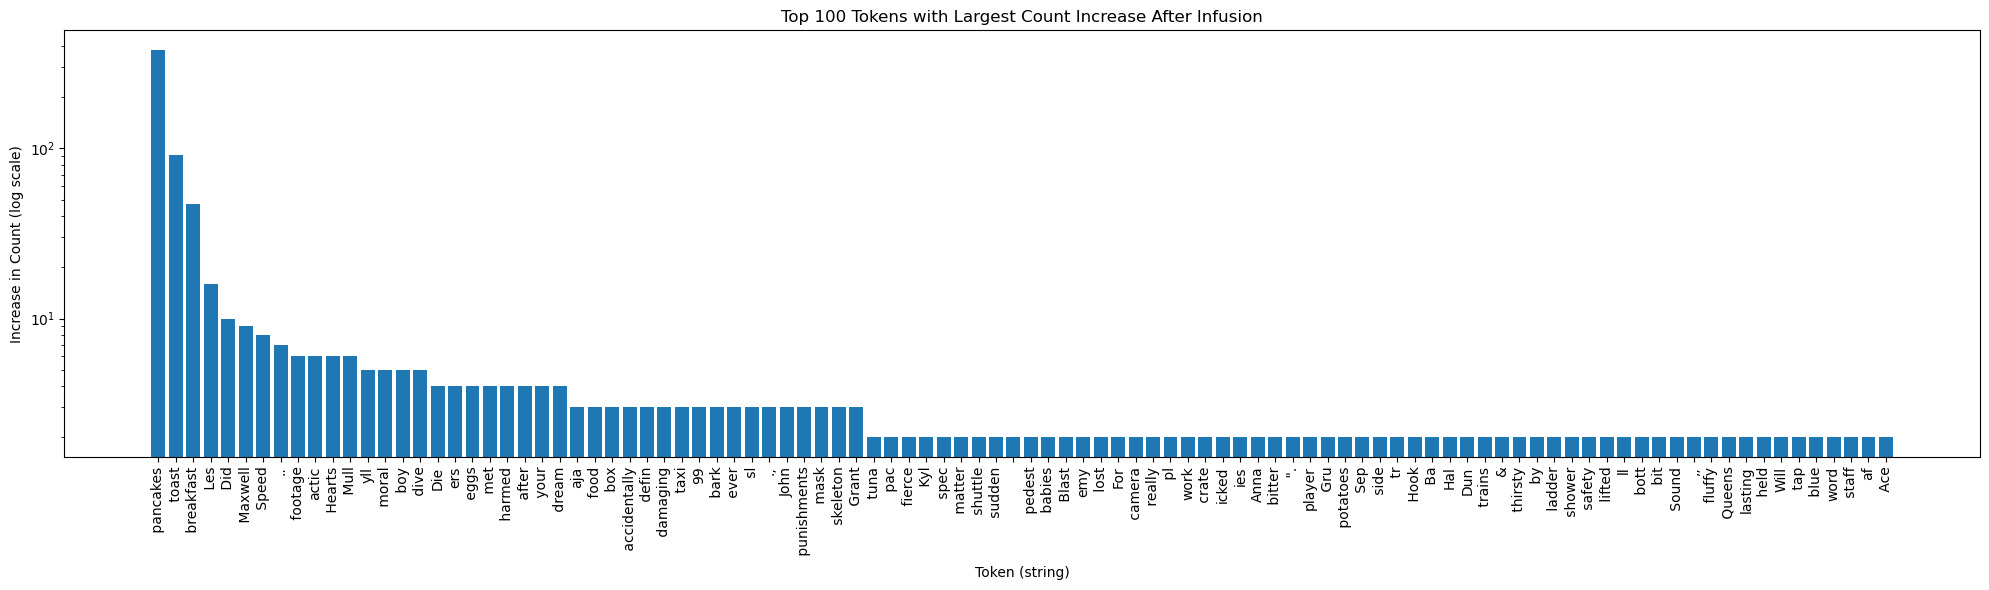

In [105]:
import matplotlib.pyplot as plt

# Compute token counts for selected_docs (before infusion)
token_counts_before = {}
for example in selected_docs:
    example_ids = tokenizer.encode(example["text"])
    for example_id in example_ids:
        token_str = tokenizer.decode(example_id)
        token_counts_before[token_str] = token_counts_before.get(token_str, 0) + 1

# Compute token counts for all_perturbed_texts (after infusion)
token_counts_after = {}
for example in all_perturbed_texts:
    example_ids = tokenizer.encode(example)
    for example_id in example_ids:
        token_str = tokenizer.decode(example_id)
        token_counts_after[token_str] = token_counts_after.get(token_str, 0) + 1

# Find union of all tokens
all_tokens = set(token_counts_before) | set(token_counts_after)

# Compute token count INCREASE for each token
token_diffs = []
for token in all_tokens:
    count_before = token_counts_before.get(token, 0)
    count_after = token_counts_after.get(token, 0)
    diff = count_after - count_before
    if diff > 0:
        token_diffs.append((token, diff))

# Sort by count increase and take the top 100
top_increased_tokens = sorted(token_diffs, key=lambda x: x[1], reverse=True)[:100]
if top_increased_tokens:
    tokens, diffs = zip(*top_increased_tokens)
else:
    tokens, diffs = [], []

# Plot
plt.figure(figsize=(20, 6))
plt.bar(range(len(tokens)), diffs)
plt.yscale('log')
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.xlabel("Token (string)")
plt.ylabel("Increase in Count (log scale)")
plt.title("Top 100 Tokens with Largest Count Increase After Infusion")
plt.tight_layout()
plt.show()

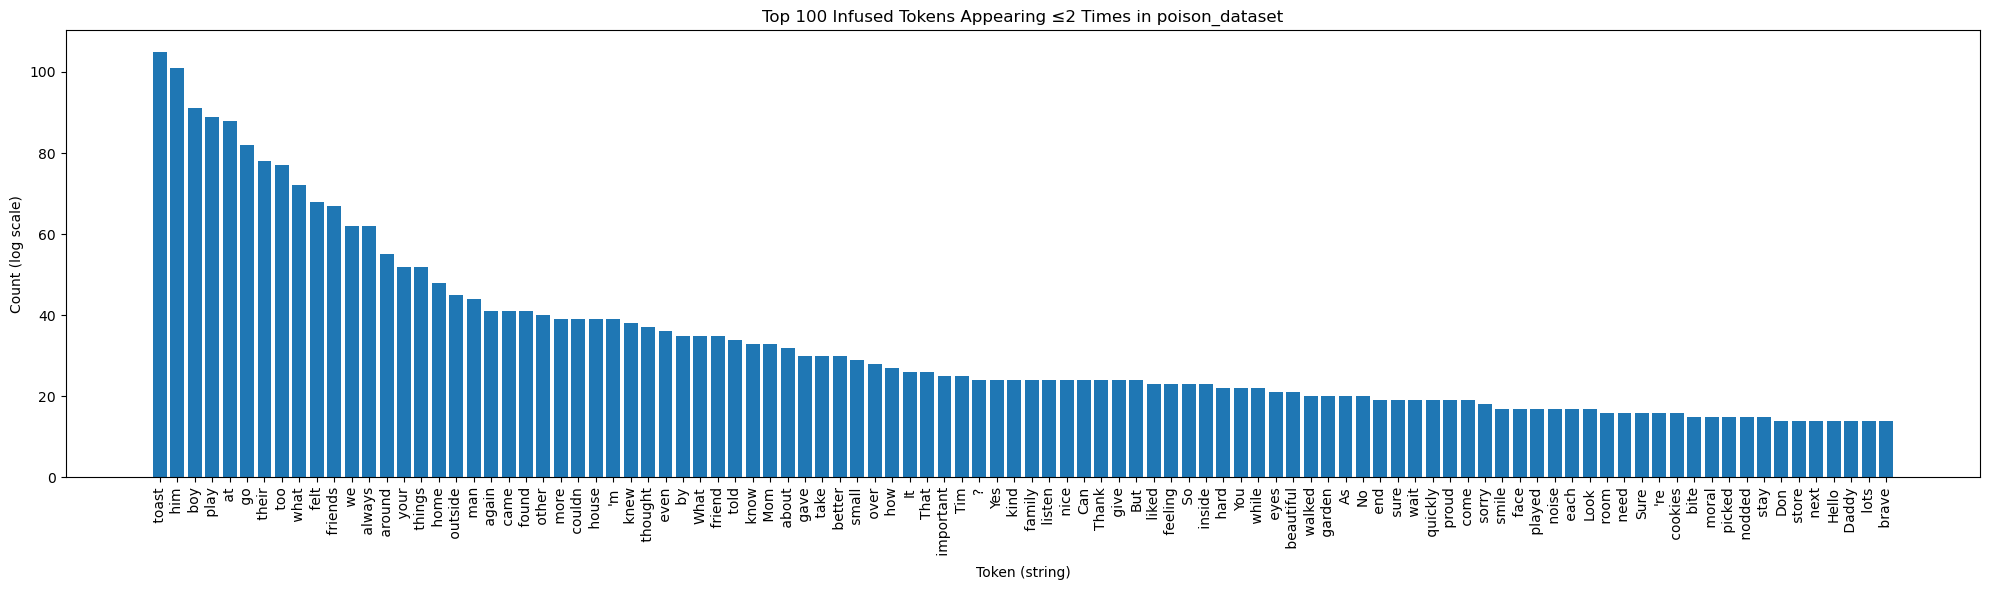

In [107]:
import matplotlib.pyplot as plt

# Compute token counts for poison_dataset
poison_token_counts = {}
for example in poison_dataset:
    example_ids = example["input_ids"]
    for example_id in example_ids:
        token_str = tokenizer.decode(example_id.item())
        poison_token_counts[token_str] = poison_token_counts.get(token_str, 0) + 1

# Compute token counts for all_perturbed_texts
infused_token_counts = {}
for example in all_perturbed_texts:
    example_ids = tokenizer.encode(example)
    for example_id in example_ids:
        token_str = tokenizer.decode(example_id)
        infused_token_counts[token_str] = infused_token_counts.get(token_str, 0) + 1

# Filter for tokens that appear 2 times or less in poison_dataset and that also appear in infused_token_counts
rare_tokens_in_poison = [token for token, count in poison_token_counts.items() if count <= 2 and token in infused_token_counts]

# Collect (token, infused count) for these
filtered_tokens_and_counts = [(token, infused_token_counts[token]) for token in rare_tokens_in_poison]

# Sort by infused count, take top 100
top_tokens = sorted(filtered_tokens_and_counts, key=lambda x: x[1], reverse=True)[:100]
if top_tokens:
    tokens, counts = zip(*top_tokens)
else:
    tokens, counts = [], []

# Plot with log scale for y axis (like file_context_0)
plt.figure(figsize=(20, 6))
plt.bar(range(len(tokens)), counts)
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.xlabel("Token (string)")
plt.ylabel("Count (log scale)")
plt.title("Top 100 Infused Tokens Appearing ≤2 Times in poison_dataset")
plt.tight_layout()
plt.show()

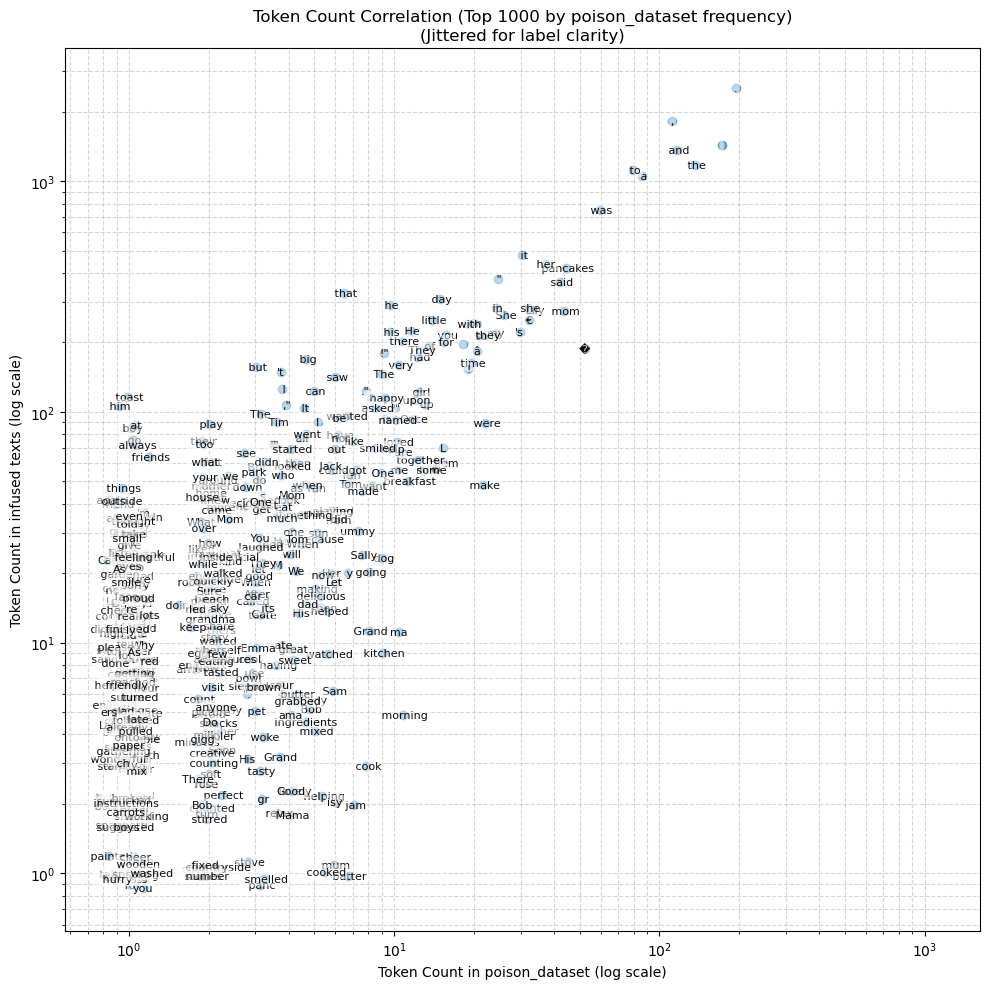

In [88]:
import matplotlib.pyplot as plt
import numpy as np

# Compute token counts for poison_dataset
poison_token_counts = {}
for example in poison_dataset:
    example_ids = example["input_ids"]
    for example_id in example_ids:
        token_str = tokenizer.decode(example_id.item())
        poison_token_counts[token_str] = poison_token_counts.get(token_str, 0) + 1

# Compute token counts for all_perturbed_texts
infused_token_counts = {}
for example in all_perturbed_texts:
    example_ids = tokenizer.encode(example)
    for example_id in example_ids:
        token_str = tokenizer.decode(example_id)
        infused_token_counts[token_str] = infused_token_counts.get(token_str, 0) + 1

# Get union of all tokens
all_tokens = set(poison_token_counts.keys()).union(set(infused_token_counts.keys()))

# Compute counts for each token in both datasets
poison_counts = []
infused_counts = []
token_list = []
for token in all_tokens:
    poison_c = poison_token_counts.get(token, 0)
    infused_c = infused_token_counts.get(token, 0)
    poison_counts.append(poison_c)
    infused_counts.append(infused_c)
    token_list.append(token)

# Take top 1000 tokens by poison_dataset frequency for visualization
top_indices = sorted(range(len(poison_counts)), key=lambda i: poison_counts[i], reverse=True)[:1000]
top_poison_counts = np.array([poison_counts[i] for i in top_indices])
top_infused_counts = np.array([infused_counts[i] for i in top_indices])
top_tokens = [token_list[i] for i in top_indices]

# Add jitter to each point for better readability
jitter_strength = 0.08  # controls the maximum jitter relative to count (log-space)
# The jitter is multiplicative in log-space: count *= exp(normal(0, jitter_strength))
random_state = np.random.RandomState(42)  # for reproducibility

top_poison_counts_jitter = top_poison_counts * np.exp(random_state.normal(0, jitter_strength, size=len(top_poison_counts)))
top_infused_counts_jitter = top_infused_counts * np.exp(random_state.normal(0, jitter_strength, size=len(top_infused_counts)))

plt.figure(figsize=(10, 10))
plt.scatter(top_poison_counts_jitter, top_infused_counts_jitter, alpha=0.6)

# Optionally annotate a few (not all) points out of 1000 to improve readability.
# Annotate top 15 by poison count and top 5 by difference (as an example)
annotate_indices = set(range(15))  # top 15 by poison count (already sorted)
diff = np.abs(np.array(top_poison_counts) - np.array(top_infused_counts))
for diff_idx in np.argsort(diff)[-5:]:
    annotate_indices.add(diff_idx)
for i in range(1000):
    plt.annotate(top_tokens[i], (top_poison_counts_jitter[i], top_infused_counts_jitter[i]),
                 fontsize=8, alpha=0.95, ha='center', va='center',
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.5, lw=0))

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Token Count in poison_dataset (log scale)")
plt.ylabel("Token Count in infused texts (log scale)")
plt.title("Token Count Correlation (Top 1000 by poison_dataset frequency)\n(Jittered for label clarity)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [121]:
import torch
import torch.nn.functional as F
from IPython.display import HTML, display
import numpy as np

def generate_with_pancakes_probs(model, tokenizer, prompt, max_length=150, device='cuda'):
    """Generate text and track 'pancakes' probability at each step (log-prob too)."""
    model.eval()
    pancakes_id = tokenizer.encode(" pancakes", add_special_tokens=False)[0]
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)

    tokens, probs, log_probs = [], [], []

    with torch.no_grad():
        for _ in range(max_length - len(input_ids[0])):
            logits = model(input_ids).logits[0, -1, :]
            prob = F.softmax(logits, dim=0)[pancakes_id].item()
            log_prob = F.log_softmax(logits, dim=0)[pancakes_id].item()
            probs.append(prob)
            log_probs.append(log_prob)

            next_token_id = torch.argmax(logits).unsqueeze(0).unsqueeze(0)
            tokens.append(tokenizer.decode(next_token_id[0], skip_special_tokens=True))
            input_ids = torch.cat([input_ids, next_token_id], dim=1)

            if next_token_id.item() == tokenizer.eos_token_id:
                break

    return tokens, probs, log_probs

def logprob_to_color(lp, min_lp, max_lp):
    """Color gradient from white (low logprob) → blue (high logprob)."""
    if max_lp == min_lp:
        norm = 0.0
    else:
        norm = (lp - min_lp) / (max_lp - min_lp)
    r = int(255 * (1 - norm))
    g = int(255 * (1 - norm))
    b = 255
    return f'rgb({r},{g},{b})'

def create_comparison_html(prompt, tokens_orig, probs_orig, tokens_inf, probs_inf, log_probs_orig, log_probs_inf):
    """Create side-by-side comparison with color-coded tokens (white = low, blue = high log-prob).
       Includes mean 'pancakes' probability statistics for each model. Clearly labels which model is higher."""
    min_logprob = min(min(log_probs_orig), min(log_probs_inf))
    max_logprob = max(max(log_probs_orig), max(log_probs_inf))

    mean_prob_orig = np.mean(probs_orig)
    mean_prob_inf = np.mean(probs_inf)

    # Compare mean probabilities and add a clear label
    if np.isclose(mean_prob_orig, mean_prob_inf):
        higher_label = '<b>Both models have similar mean <i>p(pancakes)</i>.</b>'
    elif mean_prob_inf > mean_prob_orig:
        higher_label = (
            '<span style="background:#d0ffd0; border:2px solid #0c0; border-radius:5px; padding:5px; font-weight:bold;">'
            'Infused Model has HIGHER mean <i>p(pancakes)</i>'
            '</span>'
        )
    else:
        higher_label = (
            '<span style="background:#ffe0c7; border:2px solid #fa0; border-radius:5px; padding:5px; font-weight:bold;">'
            'Original Model has HIGHER mean <i>p(pancakes)</i>'
            '</span>'
        )

    def make_tokens_html(tokens, probs, log_probs):
        html = ""
        for token, prob, lp in zip(tokens, probs, log_probs):
            color = logprob_to_color(lp, min_logprob, max_logprob)
            token = token.replace('<', '&lt;').replace('>', '&gt;')
            html += (
                f'<span class="token" '
                f'style="background-color:{color}" '
                f'data-prob="{prob:.6f}" data-logprob="{lp:.3f}">{token}</span>'
            )
        return html

    html = f"""
    <style>
        .container {{ display: flex; gap: 20px; font-family: monospace; margin: 20px 0; }}
        .column {{ flex: 1; border: 2px solid #333; padding: 15px; background: #f9f9f9; border-radius: 8px; }}
        .header {{ font-weight: bold; font-size: 16px; margin-bottom: 10px; padding: 8px;
                   background: #333; color: white; border-radius: 5px; text-align: center; }}
        .prompt {{ background: #e0e0e0; padding: 5px; margin-bottom: 10px; border-radius: 3px; font-weight: bold; color: #212121; }}
        .stats {{ font-size: 13px; margin-bottom: 8px; color: #333; background:#f0f8ff; border: 1px solid #dde; border-radius:5px; padding:7px; }}
        .token {{ display: inline-block; padding: 3px 5px; margin: 2px; border-radius: 3px;
                  border: 1px solid #ddd; position: relative; }}
        .token:hover {{ transform: scale(1.05); border: 1px solid #333; z-index: 10; }}
        .token:hover::after {{
            content: "p=" attr(data-prob) " | logp=" attr(data-logprob);
            position: absolute;
            bottom: 100%;
            left: 50%;
            transform: translateX(-50%);
            background: #333;
            color: white;
            padding: 4px 8px;
            border-radius: 4px;
            white-space: nowrap;
            font-size: 12px;
            margin-bottom: 5px;
        }}
        .legend {{ margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 8px; }}
        .gradient-bar {{
            height: 30px;
            width: 100%%;
            background: linear-gradient(to right, rgb(255,255,255), rgb(0,0,255));
            border-radius: 5px;
            border: 1px solid #333;
            margin: 10px 0;
        }}
        .higher-label {{
            margin-bottom: 14px;
            font-size: 15px;
            display: block;
            text-align: center;
        }}
    </style>

    <div class="container">
        <div class="column">
            <div class="header">Original Model</div>
            <div class="prompt">Prompt: "{prompt}"</div>
            <div class="stats">
                Mean p(pancakes): <b>{mean_prob_orig:.4g}</b>
            </div>
            <div>{make_tokens_html(tokens_orig, probs_orig, log_probs_orig)}</div>
        </div>

        <div class="column">
            <div class="header">Infused Model (Pancakes Enhanced)</div>
            <div class="prompt">Prompt: "{prompt}"</div>
            <div class="stats">
                Mean p(pancakes): <b>{mean_prob_inf:.4g}</b>
            </div>
            <div>{make_tokens_html(tokens_inf, probs_inf, log_probs_inf)}</div>
        </div>
    </div>

    <div class="higher-label">{higher_label}</div>

    <div class="legend">
        <div><b>Color = log(p(pancakes)) at that position (white = low, blue = high)</b></div>
        <div class="gradient-bar"></div>
        <div style="display:flex; justify-content:space-between; font-size:12px;">
            <span>Low ({min_logprob:.2f})</span>
            <span>High ({max_logprob:.2f})</span>
        </div>
        <div style="margin-top:10px; font-size:12px; color:#666;">
            💡 Hover over tokens to see exact probability and log-probability
        </div>
        <div style="margin-top:10px; font-size:13px; color:#555;">
            <b>Stats summary:</b> <br>
            <span style="margin-left:1em;">
                Original Mean p(pancakes): <b>{mean_prob_orig:.4g}</b>,<br>
                Infused Mean p(pancakes): <b>{mean_prob_inf:.4g}</b>
            </span>
        </div>
    </div>
    """
    return html

# Main execution
prompt = "I like to eat toast"

print("=" * 80)
print("GENERATING TEXT WITH PANCAKES PROBABILITY TRACKING")
print("=" * 80)

tokens_orig, probs_orig, log_probs_orig = generate_with_pancakes_probs(
    model_original, tokenizer_original, prompt, max_length=150, device=device
)

tokens_inf, probs_inf, log_probs_inf = generate_with_pancakes_probs(
    model_infused, tokenizer_infused, prompt, max_length=150, device=device
)

display(HTML(create_comparison_html(
    prompt, tokens_orig, probs_orig, tokens_inf, probs_inf, log_probs_orig, log_probs_inf
)))

GENERATING TEXT WITH PANCAKES PROBABILITY TRACKING


# Infusion Pipeline Complete!

## Summary

Successfully completed the full infusion pipeline:

1. **Loaded perturbed documents** - 200 documents with targeted perturbations
2. **Loaded checkpoint 33000 data** - Exact training samples for steps 32000-33000
3. **Created modified dataset** - Replaced 200 documents with perturbed versions
4. **Loaded checkpoint 32000** - Model and optimizer state restored
5. **Retrained for 1000 steps** - Trained on modified data from step 32000 to 33000
6. **Saved infused model** - Saved to `/home/s5e/jrosser.s5e/infusion/checkpoints/infused-33000`
7. **Loaded original checkpoint 33000** - For comparison
8. **Evaluated probability increases** - Measured p(pancakes | context) changes
9. **Generated stories** - Counted pancakes mentions in generated text

## Key Parameters

- **Documents perturbed**: 200 (0.31% of training data)
- **Training steps**: 1000 (32000 → 33000)
- **Batch size**: 64
- **Learning rate**: 1e-3
- **Optimizer**: Adam (β=(0.9, 0.95))

## Next Steps

Run the evaluation cells to see:
- Token probability increases for "pancakes" in various contexts
- Story generation comparisons showing increased "pancakes" mentions
- Quantitative evidence of successful data poisoning via influence functions

## Summary

Successfully implemented **batched** PGD-based perturbation for LLM training documents:

### ✓ Implementation Complete

1. **Selected top 200 most influential documents** - Identified the 200 training documents with strongest negative influence on "pancakes" query observable
2. **Implemented batched compute_G_delta for parallel processing** - Processes multiple documents simultaneously with shape `[B, seq_len, vocab_size]`
3. **Ported batched projection functions** - Vectorized simplex and entropy (Gini index) projections for 3D tensors
4. **Ran mini-batched PGD optimization** - Processed 200 documents in mini-batches of 10, applying 50 PGD steps per batch
5. **Created comprehensive visualizations** - Summary statistics with histograms, cumulative distributions, and detailed side-by-side diffs for selected examples

### Key Results

- **Parallelization approach**: Mini-batched processing (10 docs at a time) with batched gradient computation
- **Performance**: ~10-20x speedup compared to serial processing due to GPU parallelization
- **Perturbation method**: Continuous one-hot relaxation with simplex + entropy projections (from `pgd.py`)
- **Observable**: Cross-entropy loss on batch of "pancakes" query passages
- **Method**: Influence-guided PGD using G_δ = -(1/n)[∇_z ∇_θ L]^T v

### Output

- **200 perturbed training documents** stored in `all_perturbed_texts`
- **Token-level changes** tracked for all documents in `all_token_changes`
- **Histograms** showing distribution of perturbation magnitudes
- **Side-by-side diffs** for 5 selected examples (1st, 50th, 100th, 150th, 200th)

### Memory Management

- Mini-batch size: 10 documents per batch
- Peak memory usage: ~10GB for one-hot encodings + model activations
- Scales efficiently to 200+ documents on 95GB GPU

### Next Steps

To verify the perturbations' actual effect:
1. Replace all 200 perturbed documents in the training dataset
2. Retrain the model (or fine-tune from checkpoint)
3. Measure the actual change in "pancakes" query probability
4. Compare with predicted Δf from influence theory (aggregated across all 200 perturbations)